#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Import data

In [3]:
metabolites_hmdb = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/TCGA_metabolites_ensemble_nn_predicted.csv', index_col = 0)
print(metabolites_hmdb.shape)
metabolites_hmdb.head(3)

(10668, 69)


,HMDB0000870,HMDB0000848,HMDB0000714,HMDB0000191,HMDB0000251,HMDB0003229,HMDB0000562,HMDB0000252,HMDB0000696,HMDB0000641,...,HMDB0000283,HMDB0000211,HMDB0001565,HMDB0000943,HMDB0000125,HMDB0000123,HMDB0000267,HMDB0000299,HMDB0000157,HMDB0000168
TCGA-D8-A146-01A-31R-A115-07,0.472328,0.074234,-0.226336,0.124093,0.269272,0.135733,-0.094486,-0.214091,0.134839,-0.052115,...,-0.816832,-0.671293,-0.756128,-0.680072,-0.140197,-0.641231,-0.708907,-0.740135,-0.726478,-0.749646
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.399344,-0.107610,-0.163713,-0.016701,0.022655,0.271255,0.019485,-0.050806,0.143165,0.058192,...,-0.173996,0.837231,0.583765,0.420965,0.379359,0.596699,0.310625,0.240439,0.392764,0.497721
TCGA-C8-A274-01A-11R-A16F-07,0.370598,0.020797,-0.194447,0.063527,0.222715,0.027229,-0.139715,-0.168199,-0.130246,-0.150252,...,-0.449821,0.614434,0.235143,0.088601,0.063380,0.344933,0.022700,-0.173421,0.090531,0.193992


In [4]:
metabolites_hmdb = metabolites_hmdb.rename(columns = {'HMDB0000759.1' :'HMDB0000759'})

In [5]:
metabolite_names = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res/y_train_tissue_name_map.csv')
metabolite_names = metabolite_names.fillna('No_id')
metabolite_names

,Query,Match,HMDB,PubChem,ChEBI,KEGG,METLIN,SMILES,Comment
0,"1,5-anhydroglucitol (1,5-AG)",No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
1,1-arachidonoyl-GPC (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
2,1-arachidonoyl-GPE (20:4n6),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
3,1-arachidonoyl-GPI (20:4),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
4,1-linoleoylglycerol (18:2),No_id,No_id,No_id,No_id,No_id,No_id,No_id,0
...,...,...,...,...,...,...,...,...,...
213,xanthosine,Xanthosine,HMDB0000299,64959.0,18107.0,C01762,3408.0,OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=NC2=C1N=C(...,1
214,3-phosphoglycerate,3-Phosphoglyceric acid,HMDB0000807,724.0,17050.0,C00597,150.0,OC(COP(O)(O)=O)C(O)=O,1
215,dehydroascorbate,Dehydroascorbic acid,HMDB0001264,440667.0,27956.0,C05422,342.0,[H][C@@]1(OC(=O)C(=O)C1=O)[C@@H](O)CO,1
216,pyruvate,Pyruvic acid,HMDB0000243,1060.0,32816.0,C00022,117.0,CC(=O)C(O)=O,1


In [6]:
names_hmdb_dict = metabolite_names[metabolite_names['HMDB'].isin(metabolites_hmdb.columns)]
names_hmdb_dict = dict(zip(names_hmdb_dict['Query'].to_list(), names_hmdb_dict['HMDB']))
names_hmdb_dict

{'1-palmitoyl-GPE (16:0)': 'HMDB0011503',
 "2'-deoxyinosine": 'HMDB0000071',
 '4-methyl-2-oxopentanoate': 'HMDB0000695',
 '5-methylthioadenosine (MTA)': 'HMDB0001173',
 '5-oxoproline': 'HMDB0000267',
 '6-phosphogluconate': 'HMDB0001316',
 'acetylcarnitine': 'HMDB0000201',
 'alanylleucine': 'HMDB0028691',
 'arginine': 'HMDB0000517',
 'asparagine': 'HMDB0000168',
 'aspartate': 'HMDB0000191',
 'betaine': 'HMDB0000043',
 'choline': 'HMDB0000097',
 'phosphocholine': 'HMDB0001565',
 'creatine': 'HMDB0000064',
 'creatinine': 'HMDB0000562',
 'cytidine': 'HMDB0000089',
 'ergothioneine': 'HMDB0003045',
 'fructose': 'HMDB0000660',
 'fumarate': 'HMDB0000134',
 'gamma-glutamylglutamate': 'HMDB0011737',
 'gamma-glutamylvaline': 'HMDB0011172',
 'gluconate': 'HMDB0000625',
 'glutamine': 'HMDB0000641',
 'glutathione, reduced (GSH)': 'HMDB0000125',
 'glycerate': 'HMDB0000139',
 'glycerol 3-phosphate (G3P)': 'HMDB0000126',
 'glycerophosphorylcholine (GPC)': 'HMDB0000086',
 'glycine': 'HMDB0000123',
 'hip

In [7]:
hmdb_names_dict = metabolite_names[metabolite_names['HMDB'].isin(metabolites_hmdb.columns)]
hmdb_names_dict = dict(zip(hmdb_names_dict['HMDB'].to_list(), hmdb_names_dict['Query']))
hmdb_names_dict

{'HMDB0011503': '1-palmitoyl-GPE (16:0)',
 'HMDB0000071': "2'-deoxyinosine",
 'HMDB0000695': '4-methyl-2-oxopentanoate',
 'HMDB0001173': '5-methylthioadenosine (MTA)',
 'HMDB0000267': '5-oxoproline',
 'HMDB0001316': '6-phosphogluconate',
 'HMDB0000201': 'acetylcarnitine',
 'HMDB0028691': 'alanylleucine',
 'HMDB0000517': 'arginine',
 'HMDB0000168': 'asparagine',
 'HMDB0000191': 'aspartate',
 'HMDB0000043': 'betaine',
 'HMDB0000097': 'choline',
 'HMDB0001565': 'phosphocholine',
 'HMDB0000064': 'creatine',
 'HMDB0000562': 'creatinine',
 'HMDB0000089': 'cytidine',
 'HMDB0003045': 'ergothioneine',
 'HMDB0000660': 'fructose',
 'HMDB0000134': 'fumarate',
 'HMDB0011737': 'gamma-glutamylglutamate',
 'HMDB0011172': 'gamma-glutamylvaline',
 'HMDB0000625': 'gluconate',
 'HMDB0000641': 'glutamine',
 'HMDB0000125': 'glutathione, reduced (GSH)',
 'HMDB0000139': 'glycerate',
 'HMDB0000126': 'glycerol 3-phosphate (G3P)',
 'HMDB0000086': 'glycerophosphorylcholine (GPC)',
 'HMDB0000123': 'glycine',
 'HMD

In [8]:
metabolites = metabolites_hmdb.rename(columns = hmdb_names_dict)
metabolites

,histamine,stearoylcarnitine,hippurate,aspartate,taurine,palmitoleate (16:1n7),creatinine,sphingosine,methionine,glutamine,...,ribose,myo-inositol,phosphocholine,threonate,"glutathione, reduced (GSH)",glycine,5-oxoproline,xanthosine,hypoxanthine,asparagine
TCGA-D8-A146-01A-31R-A115-07,0.472328,0.074234,-0.226336,0.124093,0.269272,0.135733,-0.094486,-0.214091,0.134839,-0.052115,...,-0.816832,-0.671293,-0.756128,-0.680072,-0.140197,-0.641231,-0.708907,-0.740135,-0.726478,-0.749646
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.399344,-0.107610,-0.163713,-0.016701,0.022655,0.271255,0.019485,-0.050806,0.143165,0.058192,...,-0.173996,0.837231,0.583765,0.420965,0.379359,0.596699,0.310625,0.240439,0.392764,0.497721
TCGA-C8-A274-01A-11R-A16F-07,0.370598,0.020797,-0.194447,0.063527,0.222715,0.027229,-0.139715,-0.168199,-0.130246,-0.150252,...,-0.449821,0.614434,0.235143,0.088601,0.063380,0.344933,0.022700,-0.173421,0.090531,0.193992
TCGA-BH-A0BD-01A-11R-A034-07,0.504586,-0.091625,-0.220343,-0.022097,0.090554,0.074735,-0.029731,-0.055576,-0.063819,-0.050049,...,-0.468894,-0.205849,-0.352677,-0.333502,-0.207505,-0.258756,-0.371696,-0.374564,-0.384295,-0.345625
TCGA-B6-A1KC-01B-11R-A157-07,0.287326,-0.033126,-0.374987,0.280645,0.236876,0.074513,-0.236842,-0.179218,-0.241160,-0.281416,...,-0.074272,0.778361,0.513783,0.401898,0.051611,0.579106,0.314389,0.212994,0.376681,0.488905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-CV-7432-01A-11R-2132-07,0.285524,0.354537,-0.352333,0.117767,0.487656,-0.102301,-0.209603,0.198340,-0.156584,-0.180515,...,-0.604352,0.771068,0.452011,0.281303,0.520398,0.329496,0.228239,0.137354,0.221818,0.360751
TCGA-IQ-7630-01A-11R-2081-07,0.259172,0.421674,-0.347389,0.226844,0.659563,-0.315878,-0.132764,0.224913,-0.139061,-0.121934,...,-0.550541,0.752168,0.440438,0.281827,0.465846,0.345467,0.234216,0.121072,0.227959,0.368840
TCGA-H7-A6C4-11A-21R-A466-07,0.243144,0.551076,-0.165567,0.128711,0.506811,0.035803,0.191004,0.325823,0.186288,-0.005635,...,-0.312798,0.752792,0.495570,0.369591,0.219307,0.453286,0.317382,0.247358,0.311212,0.447961
TCGA-H7-8501-01A-11R-2403-07,0.388488,0.397901,-0.285128,0.134870,0.523280,-0.052962,-0.019246,0.200084,-0.065603,-0.074574,...,-0.092609,0.527031,0.239311,0.171391,-0.189556,0.243748,0.162871,0.190069,0.167027,0.268175


#Adding annotations

In [9]:
annot_full = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan/TCGA_Survival_Info.csv', index_col = 0)
annot_full.index.name = None
annot_full.head(3)

,type,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,initial_pathologic_dx_year,menopause_status,...,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction,pharmaceutical_treatment,radiation_treatment
TCGA-OR-A5J1,ACC,58.0,MALE,WHITE,Stage II,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],2000.0,[Not Available],...,1355.0,1.0,1355.0,1.0,754.0,1.0,754.0,NaN,NaN,NaN
TCGA-OR-A5J2,ACC,44.0,FEMALE,WHITE,Stage IV,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],2004.0,[Not Available],...,1677.0,1.0,1677.0,NaN,NaN,1.0,289.0,NaN,NaN,NaN
TCGA-OR-A5J3,ACC,23.0,FEMALE,WHITE,Stage III,[Not Applicable],Adrenocortical carcinoma- Usual Type,[Not Available],2008.0,[Not Available],...,2091.0,0.0,2091.0,1.0,53.0,1.0,53.0,NaN,NaN,NaN


In [10]:
annot = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan/TCGA_Samples_Tissue_Type.csv', index_col = 0)
annot.index.name = None
annot.head(3)

,patient_barcorde,sample_type,samples_tissue_type
TCGA-02-0047-01A-01R-1849-01,TCGA-02-0047,Tumour,TCGA-GBM
TCGA-02-0055-01A-01R-1849-01,TCGA-02-0055,Tumour,TCGA-GBM
TCGA-02-2483-01A-01R-1849-01,TCGA-02-2483,Tumour,TCGA-GBM


In [11]:
annot.shape

(10668, 3)

In [12]:
metabolites = pd.concat([annot[['sample_type', 'samples_tissue_type']], metabolites], axis = 'columns')
metabolites.head(3)

,sample_type,samples_tissue_type,histamine,stearoylcarnitine,hippurate,aspartate,taurine,palmitoleate (16:1n7),creatinine,sphingosine,...,ribose,myo-inositol,phosphocholine,threonate,"glutathione, reduced (GSH)",glycine,5-oxoproline,xanthosine,hypoxanthine,asparagine
TCGA-02-0047-01A-01R-1849-01,Tumour,TCGA-GBM,0.438751,0.174190,-0.194369,0.251118,0.404562,0.060826,-0.028997,0.024204,...,0.545640,0.891619,0.857276,0.815357,-0.431716,0.774531,0.829175,0.783448,0.811115,0.839788
TCGA-02-0055-01A-01R-1849-01,Tumour,TCGA-GBM,0.388314,0.214898,-0.339983,0.208430,0.615005,0.126682,-0.149219,-0.015704,...,0.261733,0.772575,0.611412,0.568787,-0.433918,0.631726,0.541211,0.522824,0.521643,0.618691
TCGA-02-2483-01A-01R-1849-01,Tumour,TCGA-GBM,0.428232,0.029381,-0.307771,0.180158,0.269336,-0.017946,-0.050872,-0.060907,...,0.404210,0.879451,0.800819,0.743920,-0.295814,0.723579,0.737094,0.693916,0.727737,0.773105


#Metabolite map

In [13]:
is_duplicated = metabolites.columns.duplicated()
metabolites = metabolites.loc[:, ~is_duplicated]
metabolites

,sample_type,samples_tissue_type,histamine,stearoylcarnitine,hippurate,aspartate,taurine,palmitoleate (16:1n7),creatinine,sphingosine,...,ribose,myo-inositol,phosphocholine,threonate,"glutathione, reduced (GSH)",glycine,5-oxoproline,xanthosine,hypoxanthine,asparagine
TCGA-02-0047-01A-01R-1849-01,Tumour,TCGA-GBM,0.438751,0.174190,-0.194369,0.251118,0.404562,0.060826,-0.028997,0.024204,...,0.545640,0.891619,0.857276,0.815357,-0.431716,0.774531,0.829175,0.783448,0.811115,0.839788
TCGA-02-0055-01A-01R-1849-01,Tumour,TCGA-GBM,0.388314,0.214898,-0.339983,0.208430,0.615005,0.126682,-0.149219,-0.015704,...,0.261733,0.772575,0.611412,0.568787,-0.433918,0.631726,0.541211,0.522824,0.521643,0.618691
TCGA-02-2483-01A-01R-1849-01,Tumour,TCGA-GBM,0.428232,0.029381,-0.307771,0.180158,0.269336,-0.017946,-0.050872,-0.060907,...,0.404210,0.879451,0.800819,0.743920,-0.295814,0.723579,0.737094,0.693916,0.727737,0.773105
TCGA-02-2485-01A-01R-1849-01,Tumour,TCGA-GBM,0.401977,-0.024937,-0.269656,0.308821,0.228992,0.099921,-0.094120,-0.177110,...,0.218267,0.869618,0.768375,0.685791,-0.108774,0.672833,0.676221,0.612539,0.662356,0.721982
TCGA-02-2486-01A-01R-1849-01,Tumour,TCGA-GBM,0.352240,0.017285,-0.317541,0.183377,0.459283,0.085057,-0.196090,-0.162359,...,0.374308,0.800639,0.664524,0.644201,-0.511033,0.666639,0.618614,0.599696,0.602795,0.677466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-ZS-A9CG-01A-11R-A37K-07,Tumour,TCGA-LIHC,0.226919,0.847485,0.444657,0.701479,0.551141,0.574976,0.640671,0.882385,...,0.502889,0.833014,0.733321,0.726001,-0.554611,0.734684,0.705327,0.671779,0.689043,0.755490
TCGA-ZT-A8OM-01A-11R-A42S-07,Tumour,TCGA-THYM,0.371971,0.001452,-0.330450,0.280216,0.417151,0.013898,-0.126370,-0.240093,...,-0.211679,0.410580,0.098906,-0.031290,-0.434509,0.158135,-0.015691,-0.067758,-0.011852,0.082715
TCGA-ZU-A8S4-01A-11R-A41I-07,Tumour,TCGA-CHOL,0.384887,0.070832,-0.260524,0.269223,0.559935,0.242973,0.003320,0.013695,...,0.092116,0.604028,0.376059,0.325817,-0.388004,0.453669,0.283898,0.322508,0.259446,0.390024
TCGA-ZU-A8S4-11A-11R-A41I-07,Normal,TCGA-CHOL,0.249784,0.793735,0.377385,0.904313,0.698886,0.601658,0.653481,0.731311,...,0.343615,0.596141,0.418802,0.418712,-0.556947,0.545944,0.330263,0.403739,0.302341,0.437158


In [14]:
metabolites.head(3)

,sample_type,samples_tissue_type,histamine,stearoylcarnitine,hippurate,aspartate,taurine,palmitoleate (16:1n7),creatinine,sphingosine,...,ribose,myo-inositol,phosphocholine,threonate,"glutathione, reduced (GSH)",glycine,5-oxoproline,xanthosine,hypoxanthine,asparagine
TCGA-02-0047-01A-01R-1849-01,Tumour,TCGA-GBM,0.438751,0.174190,-0.194369,0.251118,0.404562,0.060826,-0.028997,0.024204,...,0.545640,0.891619,0.857276,0.815357,-0.431716,0.774531,0.829175,0.783448,0.811115,0.839788
TCGA-02-0055-01A-01R-1849-01,Tumour,TCGA-GBM,0.388314,0.214898,-0.339983,0.208430,0.615005,0.126682,-0.149219,-0.015704,...,0.261733,0.772575,0.611412,0.568787,-0.433918,0.631726,0.541211,0.522824,0.521643,0.618691
TCGA-02-2483-01A-01R-1849-01,Tumour,TCGA-GBM,0.428232,0.029381,-0.307771,0.180158,0.269336,-0.017946,-0.050872,-0.060907,...,0.404210,0.879451,0.800819,0.743920,-0.295814,0.723579,0.737094,0.693916,0.727737,0.773105


In [15]:
map_metadata = metabolites[['sample_type', 'samples_tissue_type']]
map_metadata['samples_tissue_type'] = map_metadata['samples_tissue_type'].map(lambda x: x.split('-')[1])
map_metadata

/tmp/ipython-input-612389708.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  map_metadata['samples_tissue_type'] = map_metadata['samples_tissue_type'].map(lambda x: x.split('-')[1])


,sample_type,samples_tissue_type
TCGA-02-0047-01A-01R-1849-01,Tumour,GBM
TCGA-02-0055-01A-01R-1849-01,Tumour,GBM
TCGA-02-2483-01A-01R-1849-01,Tumour,GBM
TCGA-02-2485-01A-01R-1849-01,Tumour,GBM
TCGA-02-2486-01A-01R-1849-01,Tumour,GBM
...,...,...
TCGA-ZS-A9CG-01A-11R-A37K-07,Tumour,LIHC
TCGA-ZT-A8OM-01A-11R-A42S-07,Tumour,THYM
TCGA-ZU-A8S4-01A-11R-A41I-07,Tumour,CHOL
TCGA-ZU-A8S4-11A-11R-A41I-07,Normal,CHOL


In [16]:
from matplotlib import colormaps

map_metadata_melted = map_metadata.melt(value_vars=['sample_type', 'samples_tissue_type'], value_name='value')


palettes = ['tab20', 'Set3', 'Dark2']
colors = []
for p in palettes:
    colors.extend(colormaps.get_cmap(p)(range(colormaps.get_cmap(p).N)))

values = map_metadata_melted['value'].value_counts().index.to_list()
n = len(values) # Define n here

colors = colors[:n]  # trim to needed number

lut = {
    value: '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))
    for value, (r, g, b, _) in zip(values, colors)
}

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


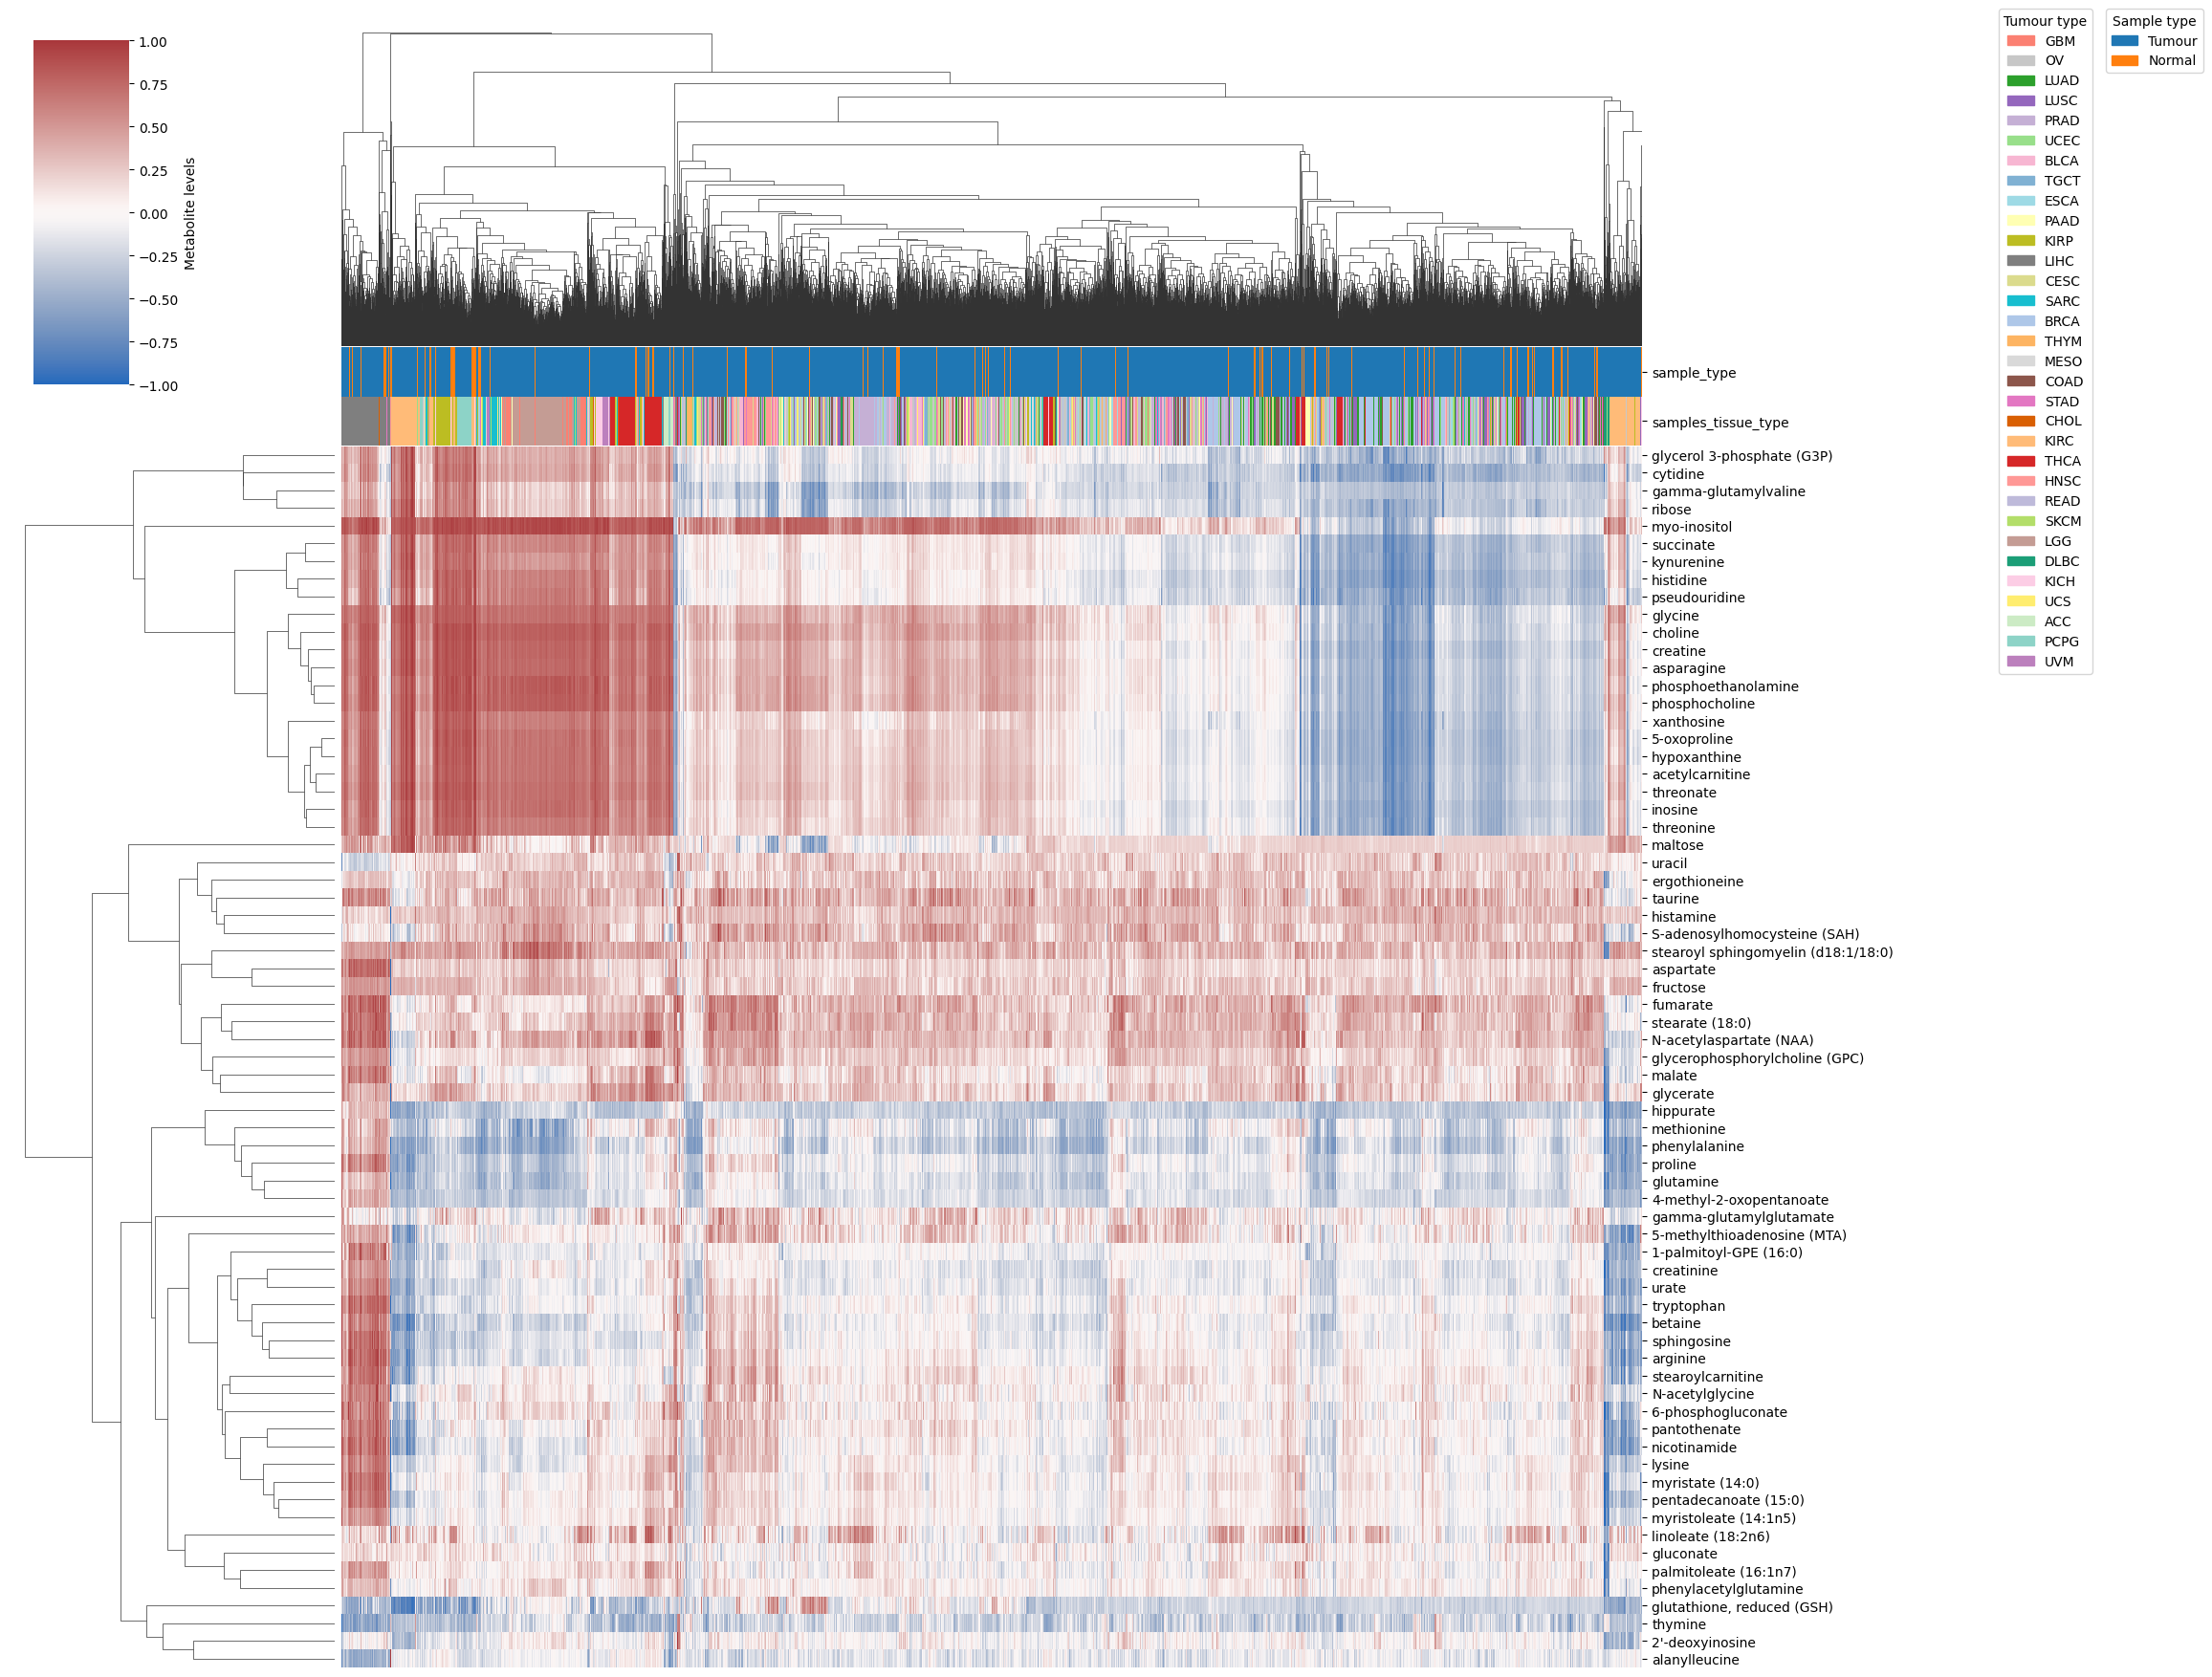

In [17]:
from matplotlib.colors import LinearSegmentedColormap

# colors = ["#00008B", "white", "#8B0000"]  # blue → white → red
# cmap = LinearSegmentedColormap.from_list("my_cmap", colors)
cmap = sns.color_palette("vlag", as_cmap=True)

col_colors = map_metadata.apply(lambda x: x.map(lut))

g = sns.clustermap(metabolites.drop(labels = ['sample_type', 'samples_tissue_type'], axis = 'columns').T,
                   cmap = cmap,
                  #  col_cluster=False,
                   col_colors = col_colors,
                   figsize=(20,20))

plt.ylabel('Metabolite levels')
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)


import matplotlib.patches as mpatches

sample_type_patches = [mpatches.Patch(color=lut[label], label=label) for label in map_metadata['sample_type'].unique()]
samples_tissue_type_patches = [mpatches.Patch(color=lut[label], label=label) for label in map_metadata['samples_tissue_type'].unique()]


# Add the legends to the figure
g.fig.legend(handles=sample_type_patches, title="Sample type", loc="upper left", bbox_to_anchor=(1.1, 1), ncol=1)
g.fig.legend(handles=samples_tissue_type_patches, title="Tumour type", loc="upper right", bbox_to_anchor=(1.1, 1), ncol=1)

g.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_metabolites_ensemble_nn_clustermap_metabolites.svg', format = 'svg')
plt.show()

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(metabolites.drop(labels = ['sample_type', 'samples_tissue_type'], axis = 'columns'))
pca_df = pd.DataFrame(pca_result, columns = ['PC1', 'PC2'], index = metabolites.index)
pca_df

,PC1,PC2
TCGA-02-0047-01A-01R-1849-01,3.110316,-0.377045
TCGA-02-0055-01A-01R-1849-01,1.818078,0.006477
TCGA-02-2483-01A-01R-1849-01,2.690551,-0.541745
TCGA-02-2485-01A-01R-1849-01,2.409922,-0.565827
TCGA-02-2486-01A-01R-1849-01,2.217590,-0.633806
...,...,...
TCGA-ZS-A9CG-01A-11R-A37K-07,2.501864,3.821219
TCGA-ZT-A8OM-01A-11R-A42S-07,-0.629340,-0.378167
TCGA-ZU-A8S4-01A-11R-A41I-07,0.767907,0.489873
TCGA-ZU-A8S4-11A-11R-A41I-07,1.066491,3.881020


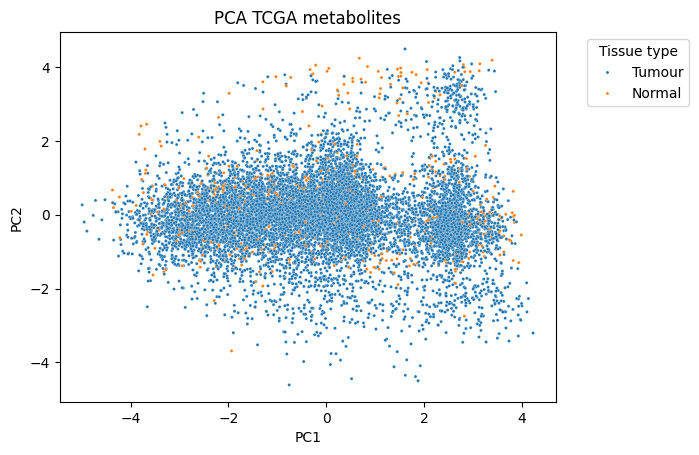

In [19]:
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', hue = map_metadata['sample_type'], s = 5)
plt.title('PCA TCGA metabolites')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title = 'Tissue type')
plt.show()

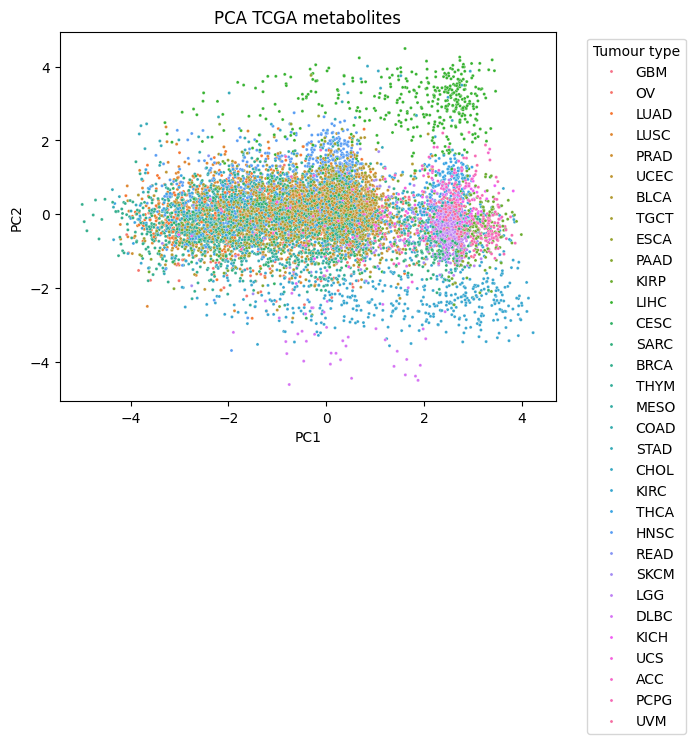

In [20]:
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', hue = map_metadata['samples_tissue_type'], s = 5)
plt.title('PCA TCGA metabolites')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title = 'Tumour type')
plt.show()

In [21]:
!pip install umap-learn --quiet
import umap

In [22]:
reducer = umap.UMAP(n_components=2, n_neighbors = 5)
umap_result = reducer.fit_transform(metabolites.drop(labels = ['sample_type', 'samples_tissue_type'], axis = 'columns'))
umap_df = pd.DataFrame(umap_result, columns = ['UMAP1', 'UMAP2'], index = metabolites.index)
umap_df

,UMAP1,UMAP2
TCGA-02-0047-01A-01R-1849-01,-2.391154,11.550140
TCGA-02-0055-01A-01R-1849-01,-0.009875,10.517331
TCGA-02-2483-01A-01R-1849-01,-2.016077,11.766792
TCGA-02-2485-01A-01R-1849-01,-2.251546,12.221526
TCGA-02-2486-01A-01R-1849-01,-0.781436,11.453055
...,...,...
TCGA-ZS-A9CG-01A-11R-A37K-07,4.047449,-1.256838
TCGA-ZT-A8OM-01A-11R-A42S-07,9.402761,9.544174
TCGA-ZU-A8S4-01A-11R-A41I-07,5.289096,7.186227
TCGA-ZU-A8S4-11A-11R-A41I-07,5.040524,-0.680785


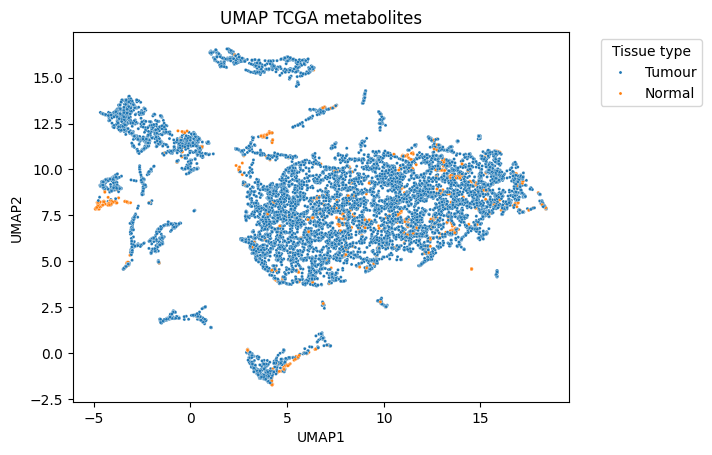

In [23]:
sns.scatterplot(data = umap_df, x = 'UMAP1', y = 'UMAP2', hue = map_metadata['sample_type'], s = 5)
plt.title('UMAP TCGA metabolites')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title = 'Tissue type')
plt.show()

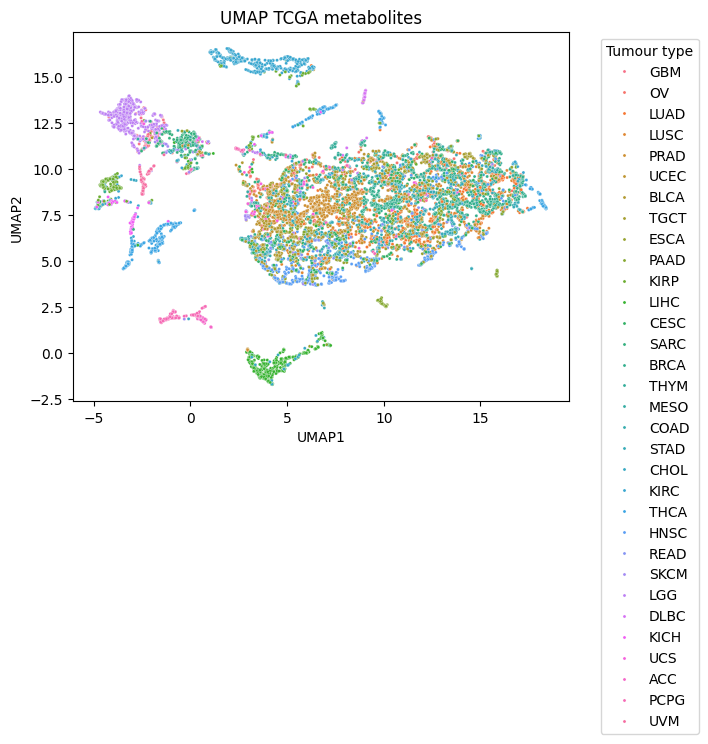

In [24]:
sns.scatterplot(data = umap_df, x = 'UMAP1', y = 'UMAP2', hue = map_metadata['samples_tissue_type'], s = 5)
plt.title('UMAP TCGA metabolites')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title = 'Tumour type')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_metabolites_ensemble_nn_umap.svg')
plt.show()

#ssPA

In [25]:
!pip install gseapy
import gseapy as gp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 10.5 MB/s eta 0:00:00


In [26]:
met_db = pd.read_csv('drive/My Drive/Colab Notebooks/pathbank_pathway_hmdb.csv')
met_db = met_db.dropna()
met_db

,Pathway Name,HMDB ID
0,Alanine Metabolism,HMDB0000538
1,Alanine Metabolism,HMDB0000161
2,Alanine Metabolism,HMDB0000045
3,Alanine Metabolism,HMDB0000250
4,Alanine Metabolism,HMDB0001303
...,...,...
1977776,Methylglyoxal Degradation I,HMDB0000190
1977777,Methylglyoxal Degradation I,HMDB0015532
1977778,Methylglyoxal Degradation I,HMDB0036062
1977779,Methylglyoxal Degradation I,HMDB0000243


In [27]:
len(met_db['Pathway Name'].unique())

68355

In [28]:
met_db_dict = met_db.groupby('Pathway Name')['HMDB ID'].apply(list).to_dict()
len(met_db_dict)

68355

In [29]:
metabolites_hmdb.T

,TCGA-D8-A146-01A-31R-A115-07,TCGA-AQ-A0Y5-01A-11R-A14M-07,TCGA-C8-A274-01A-11R-A16F-07,TCGA-BH-A0BD-01A-11R-A034-07,TCGA-B6-A1KC-01B-11R-A157-07,TCGA-AC-A62V-01A-11R-A31O-07,TCGA-AO-A0J5-01A-11R-A034-07,TCGA-BH-A0B1-01A-12R-A056-07,TCGA-A2-A0YM-01A-11R-A109-07,TCGA-AO-A03N-01B-11R-A10J-07,...,TCGA-HD-7753-01A-11R-2081-07,TCGA-CV-A6JE-01A-11R-A31N-07,TCGA-CV-A45Z-01A-21R-A24Z-07,TCGA-CV-6939-11A-01R-1915-07,TCGA-CV-7432-11A-01R-2132-07,TCGA-CV-7432-01A-11R-2132-07,TCGA-IQ-7630-01A-11R-2081-07,TCGA-H7-A6C4-11A-21R-A466-07,TCGA-H7-8501-01A-11R-2403-07,TCGA-CV-7415-01A-11R-2081-07
HMDB0000870,0.472328,0.399344,0.370598,0.504586,0.287326,0.397681,0.334774,0.276590,0.325265,0.256587,...,0.370540,0.408323,0.249376,0.397534,-0.239234,0.285524,0.259172,0.243144,0.388488,0.308340
HMDB0000848,0.074234,-0.107610,0.020797,-0.091625,-0.033126,0.271211,-0.075664,0.009287,-0.061383,-0.083202,...,0.294020,0.305056,0.543198,0.171665,-0.045101,0.354537,0.421674,0.551076,0.397901,0.515444
HMDB0000714,-0.226336,-0.163713,-0.194447,-0.220343,-0.374987,-0.386130,-0.365858,-0.218163,-0.379054,-0.319051,...,-0.362147,-0.324535,-0.190754,-0.315857,-0.717546,-0.352333,-0.347389,-0.165567,-0.285128,-0.286777
HMDB0000191,0.124093,-0.016701,0.063527,-0.022097,0.280645,0.141524,0.162282,0.087193,0.091355,0.002233,...,0.225684,0.134022,0.193915,0.118151,-0.048915,0.117767,0.226844,0.128711,0.134870,0.225427
HMDB0000251,0.269272,0.022655,0.222715,0.090554,0.236876,0.574575,0.301130,0.252843,0.183199,0.265458,...,0.381636,0.594105,0.537959,0.481095,-0.262689,0.487656,0.659563,0.506811,0.523280,0.566862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HMDB0000123,-0.641231,0.596699,0.344933,-0.258756,0.579106,0.460342,-0.162696,0.074643,0.161784,0.318216,...,-0.046135,0.340138,0.153978,0.033442,-0.347296,0.329496,0.345467,0.453286,0.243748,0.015499
HMDB0000267,-0.708907,0.310625,0.022700,-0.371696,0.314389,0.219051,-0.313643,-0.117848,0.060044,0.031505,...,-0.118697,0.239739,0.063988,-0.142208,-0.396402,0.228239,0.234216,0.317382,0.162871,-0.093352
HMDB0000299,-0.740135,0.240439,-0.173421,-0.374564,0.212994,0.111121,-0.332042,-0.192621,0.091733,-0.099373,...,-0.050123,0.230856,0.115347,-0.144707,-0.365722,0.137354,0.121072,0.247358,0.190069,-0.060466
HMDB0000157,-0.726478,0.392764,0.090531,-0.384295,0.376681,0.247291,-0.323248,-0.104000,0.060610,0.077394,...,-0.111677,0.241076,0.070198,-0.151112,-0.411374,0.221818,0.227959,0.311212,0.167027,-0.080595


In [30]:
#This function performs ssgsea and returns the results

def perform_sspa(df, gene_set_library):
  result = pd.DataFrame()

  for sample_id in df.columns:
    sample = df[sample_id]
    ssgsea_results = gp.ssgsea(data=sample, gene_sets=gene_set_library, outdir=None, min_size = 5)
    enrichment_scores = ssgsea_results.res2d
    sample_result = pd.DataFrame()
    for i in enrichment_scores['Name'].unique():
      sample_es = enrichment_scores[enrichment_scores['Name'] == i]
      sample_es = sample_es.rename(columns = {'Term' : ''})
      sample_es = sample_es.set_index('')
      sample_es = sample_es.drop(columns = ['Name', 'ES'])
      sample_es = sample_es.rename(columns = {'NES' : i})
      sample_result = pd.concat([sample_result, sample_es], axis = 'columns')
    result = pd.concat([result, sample_result], axis = 'columns')

  return result

# sspa_res = perform_sspa(df = metabolites_hmdb.T, gene_set_library = met_db_dict)
# sspa_res.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/sspa_res.csv')
# sspa_res

sspa_res = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/sspa_res.csv', index_col = 0)
sspa_res

,TCGA-D8-A146-01A-31R-A115-07,TCGA-AQ-A0Y5-01A-11R-A14M-07,TCGA-C8-A274-01A-11R-A16F-07,TCGA-BH-A0BD-01A-11R-A034-07,TCGA-B6-A1KC-01B-11R-A157-07,TCGA-AC-A62V-01A-11R-A31O-07,TCGA-AO-A0J5-01A-11R-A034-07,TCGA-BH-A0B1-01A-12R-A056-07,TCGA-A2-A0YM-01A-11R-A109-07,TCGA-AO-A03N-01B-11R-A10J-07,...,TCGA-HD-7753-01A-11R-2081-07,TCGA-CV-A6JE-01A-11R-A31N-07,TCGA-CV-A45Z-01A-21R-A24Z-07,TCGA-CV-6939-11A-01R-1915-07,TCGA-CV-7432-11A-01R-2132-07,TCGA-CV-7432-01A-11R-2132-07,TCGA-IQ-7630-01A-11R-2081-07,TCGA-H7-A6C4-11A-21R-A466-07,TCGA-H7-8501-01A-11R-2403-07,TCGA-CV-7415-01A-11R-2081-07
Aspartate Metabolism,0.584839,0.481400,0.556324,0.429649,0.483041,0.627304,0.479138,0.457507,0.540864,0.374556,...,0.547613,0.797584,0.330378,0.554032,0.153681,0.383821,0.555499,0.240170,0.755405,0.478391
Glutaminolysis and Cancer,0.574092,0.515766,0.639858,0.464700,0.465555,0.540691,0.631719,0.571833,0.504340,0.373641,...,0.442665,0.517641,0.215600,0.433884,0.034113,0.171043,0.381888,-0.034040,0.524882,0.325714
Inner Membrane Transport,0.525158,0.360453,0.367353,0.304789,0.307509,0.501874,0.554783,0.596997,0.387913,0.583686,...,0.220563,0.516098,0.257148,0.394607,-0.156093,0.296522,0.285882,0.199930,0.408184,0.317582
Hypoacetylaspartia,0.444676,0.401834,0.519825,0.287750,0.540470,0.653247,0.320787,0.302871,0.468664,0.472427,...,0.636903,0.836831,0.337136,0.549621,0.074566,0.462568,0.548220,0.295386,0.687502,0.427069
Canavan Disease,0.444676,0.401834,0.519825,0.287750,0.540470,0.653247,0.320787,0.302871,0.468664,0.472427,...,0.636903,0.836831,0.337136,0.549621,0.074566,0.462568,0.548220,0.295386,0.687502,0.427069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tRNA Charging,-0.049734,-0.189251,-0.283881,-0.305778,-0.221571,-0.100328,-0.107213,-0.020270,-0.384105,-0.051986,...,-0.171226,0.059676,0.176097,-0.425023,-0.156735,-0.057045,-0.099296,-0.011632,-0.154287,0.009761
Nicotinate and Nicotinamide Metabolism,0.040019,0.002042,0.231676,0.038579,-0.009061,0.374104,0.041183,-0.106111,0.148290,0.047887,...,0.511119,0.346453,0.245417,0.381751,-0.072433,0.224772,0.203202,0.111810,0.187870,0.243084
Thioguanine Action Pathway,0.037722,0.400606,0.449337,0.181218,0.473874,0.490070,0.020844,0.145391,0.292619,0.339150,...,0.329707,0.387513,0.131843,0.189170,-0.071384,0.293427,0.317091,0.108084,0.220749,0.082368
Mercaptopurine Action Pathway,0.037722,0.400606,0.449337,0.181218,0.473874,0.490070,0.020844,0.145391,0.292619,0.339150,...,0.329707,0.387513,0.131843,0.189170,-0.071384,0.293427,0.317091,0.108084,0.220749,0.082368


In [31]:
sspa_res = sspa_res.fillna(0)

In [32]:
keep_cols = ['Aspartate Metabolism', 'Glutaminolysis and Cancer',
       'Inner Membrane Transport', 'NAD Metabolism', 'beta-Alanine Metabolism',
       'Urea Cycle',  'Warburg Effect',
       'Arginine and Proline Metabolism',
       'Proline Metabolism', 'Arginine Metabolism',
       'Glycine and Serine Metabolism',
       'Purine Metabolism',
       'Methionine Metabolism', 'Tryptophan Metabolism',
       'Pyrimidine Metabolism',
       'Lysolipid Incorporation into ER PC(16:0/16:0)',
       'Nicotinate and Nicotinamide Metabolism']
sspa_res_keep_cols = sspa_res.reindex(keep_cols, axis = 'index')
sspa_res_keep_cols

,TCGA-D8-A146-01A-31R-A115-07,TCGA-AQ-A0Y5-01A-11R-A14M-07,TCGA-C8-A274-01A-11R-A16F-07,TCGA-BH-A0BD-01A-11R-A034-07,TCGA-B6-A1KC-01B-11R-A157-07,TCGA-AC-A62V-01A-11R-A31O-07,TCGA-AO-A0J5-01A-11R-A034-07,TCGA-BH-A0B1-01A-12R-A056-07,TCGA-A2-A0YM-01A-11R-A109-07,TCGA-AO-A03N-01B-11R-A10J-07,...,TCGA-HD-7753-01A-11R-2081-07,TCGA-CV-A6JE-01A-11R-A31N-07,TCGA-CV-A45Z-01A-21R-A24Z-07,TCGA-CV-6939-11A-01R-1915-07,TCGA-CV-7432-11A-01R-2132-07,TCGA-CV-7432-01A-11R-2132-07,TCGA-IQ-7630-01A-11R-2081-07,TCGA-H7-A6C4-11A-21R-A466-07,TCGA-H7-8501-01A-11R-2403-07,TCGA-CV-7415-01A-11R-2081-07
Aspartate Metabolism,0.584839,0.481400,0.556324,0.429649,0.483041,0.627304,0.479138,0.457507,0.540864,0.374556,...,0.547613,0.797584,0.330378,0.554032,0.153681,0.383821,0.555499,0.240170,0.755405,0.478391
Glutaminolysis and Cancer,0.574092,0.515766,0.639858,0.464700,0.465555,0.540691,0.631719,0.571833,0.504340,0.373641,...,0.442665,0.517641,0.215600,0.433884,0.034113,0.171043,0.381888,-0.034040,0.524882,0.325714
Inner Membrane Transport,0.525158,0.360453,0.367353,0.304789,0.307509,0.501874,0.554783,0.596997,0.387913,0.583686,...,0.220563,0.516098,0.257148,0.394607,-0.156093,0.296522,0.285882,0.199930,0.408184,0.317582
NAD Metabolism,-0.415161,-0.298739,-0.360142,-0.447953,-0.220036,-0.202691,-0.368281,-0.403003,-0.354032,-0.273696,...,0.065800,-0.113133,-0.035374,-0.293669,-0.307219,-0.149606,-0.254226,-0.143032,-0.244595,-0.096537
beta-Alanine Metabolism,0.384924,0.127335,0.468657,0.157182,0.174709,0.467801,0.342078,0.403347,0.342951,0.354868,...,0.301812,0.559578,0.188445,0.344196,0.361554,0.169790,0.389120,0.063686,0.392171,0.145825
Urea Cycle,0.380130,0.240161,0.472081,0.255078,0.309524,0.529849,0.324940,0.270164,0.194858,0.383574,...,0.640382,0.631360,0.377308,0.463785,-0.005430,0.328069,0.456393,0.173425,0.564740,0.413195
Warburg Effect,0.374009,0.701261,0.554077,0.552047,0.217031,0.650924,0.411037,0.527368,0.205208,0.408215,...,0.395919,0.679197,0.421195,0.450003,-0.192728,0.232165,0.293602,0.162612,0.644092,0.474413
Arginine and Proline Metabolism,0.326895,0.333799,0.612713,0.204628,0.480780,0.797309,0.312634,0.318165,0.383977,0.546918,...,0.708456,0.886867,0.446221,0.551635,-0.054003,0.545493,0.603563,0.295593,0.684714,0.463213
Proline Metabolism,0.232080,0.072391,0.272433,0.144006,0.098306,0.360433,0.210158,0.188022,0.008852,0.176263,...,0.498403,0.514984,0.403967,0.203441,-0.104123,0.225476,0.334244,0.095135,0.439678,0.377220
Arginine Metabolism,0.232080,0.072391,0.272433,0.144006,0.098306,0.360433,0.210158,0.188022,0.008852,0.176263,...,0.498403,0.514984,0.403967,0.203441,-0.104123,0.225476,0.334244,0.095135,0.439678,0.377220


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


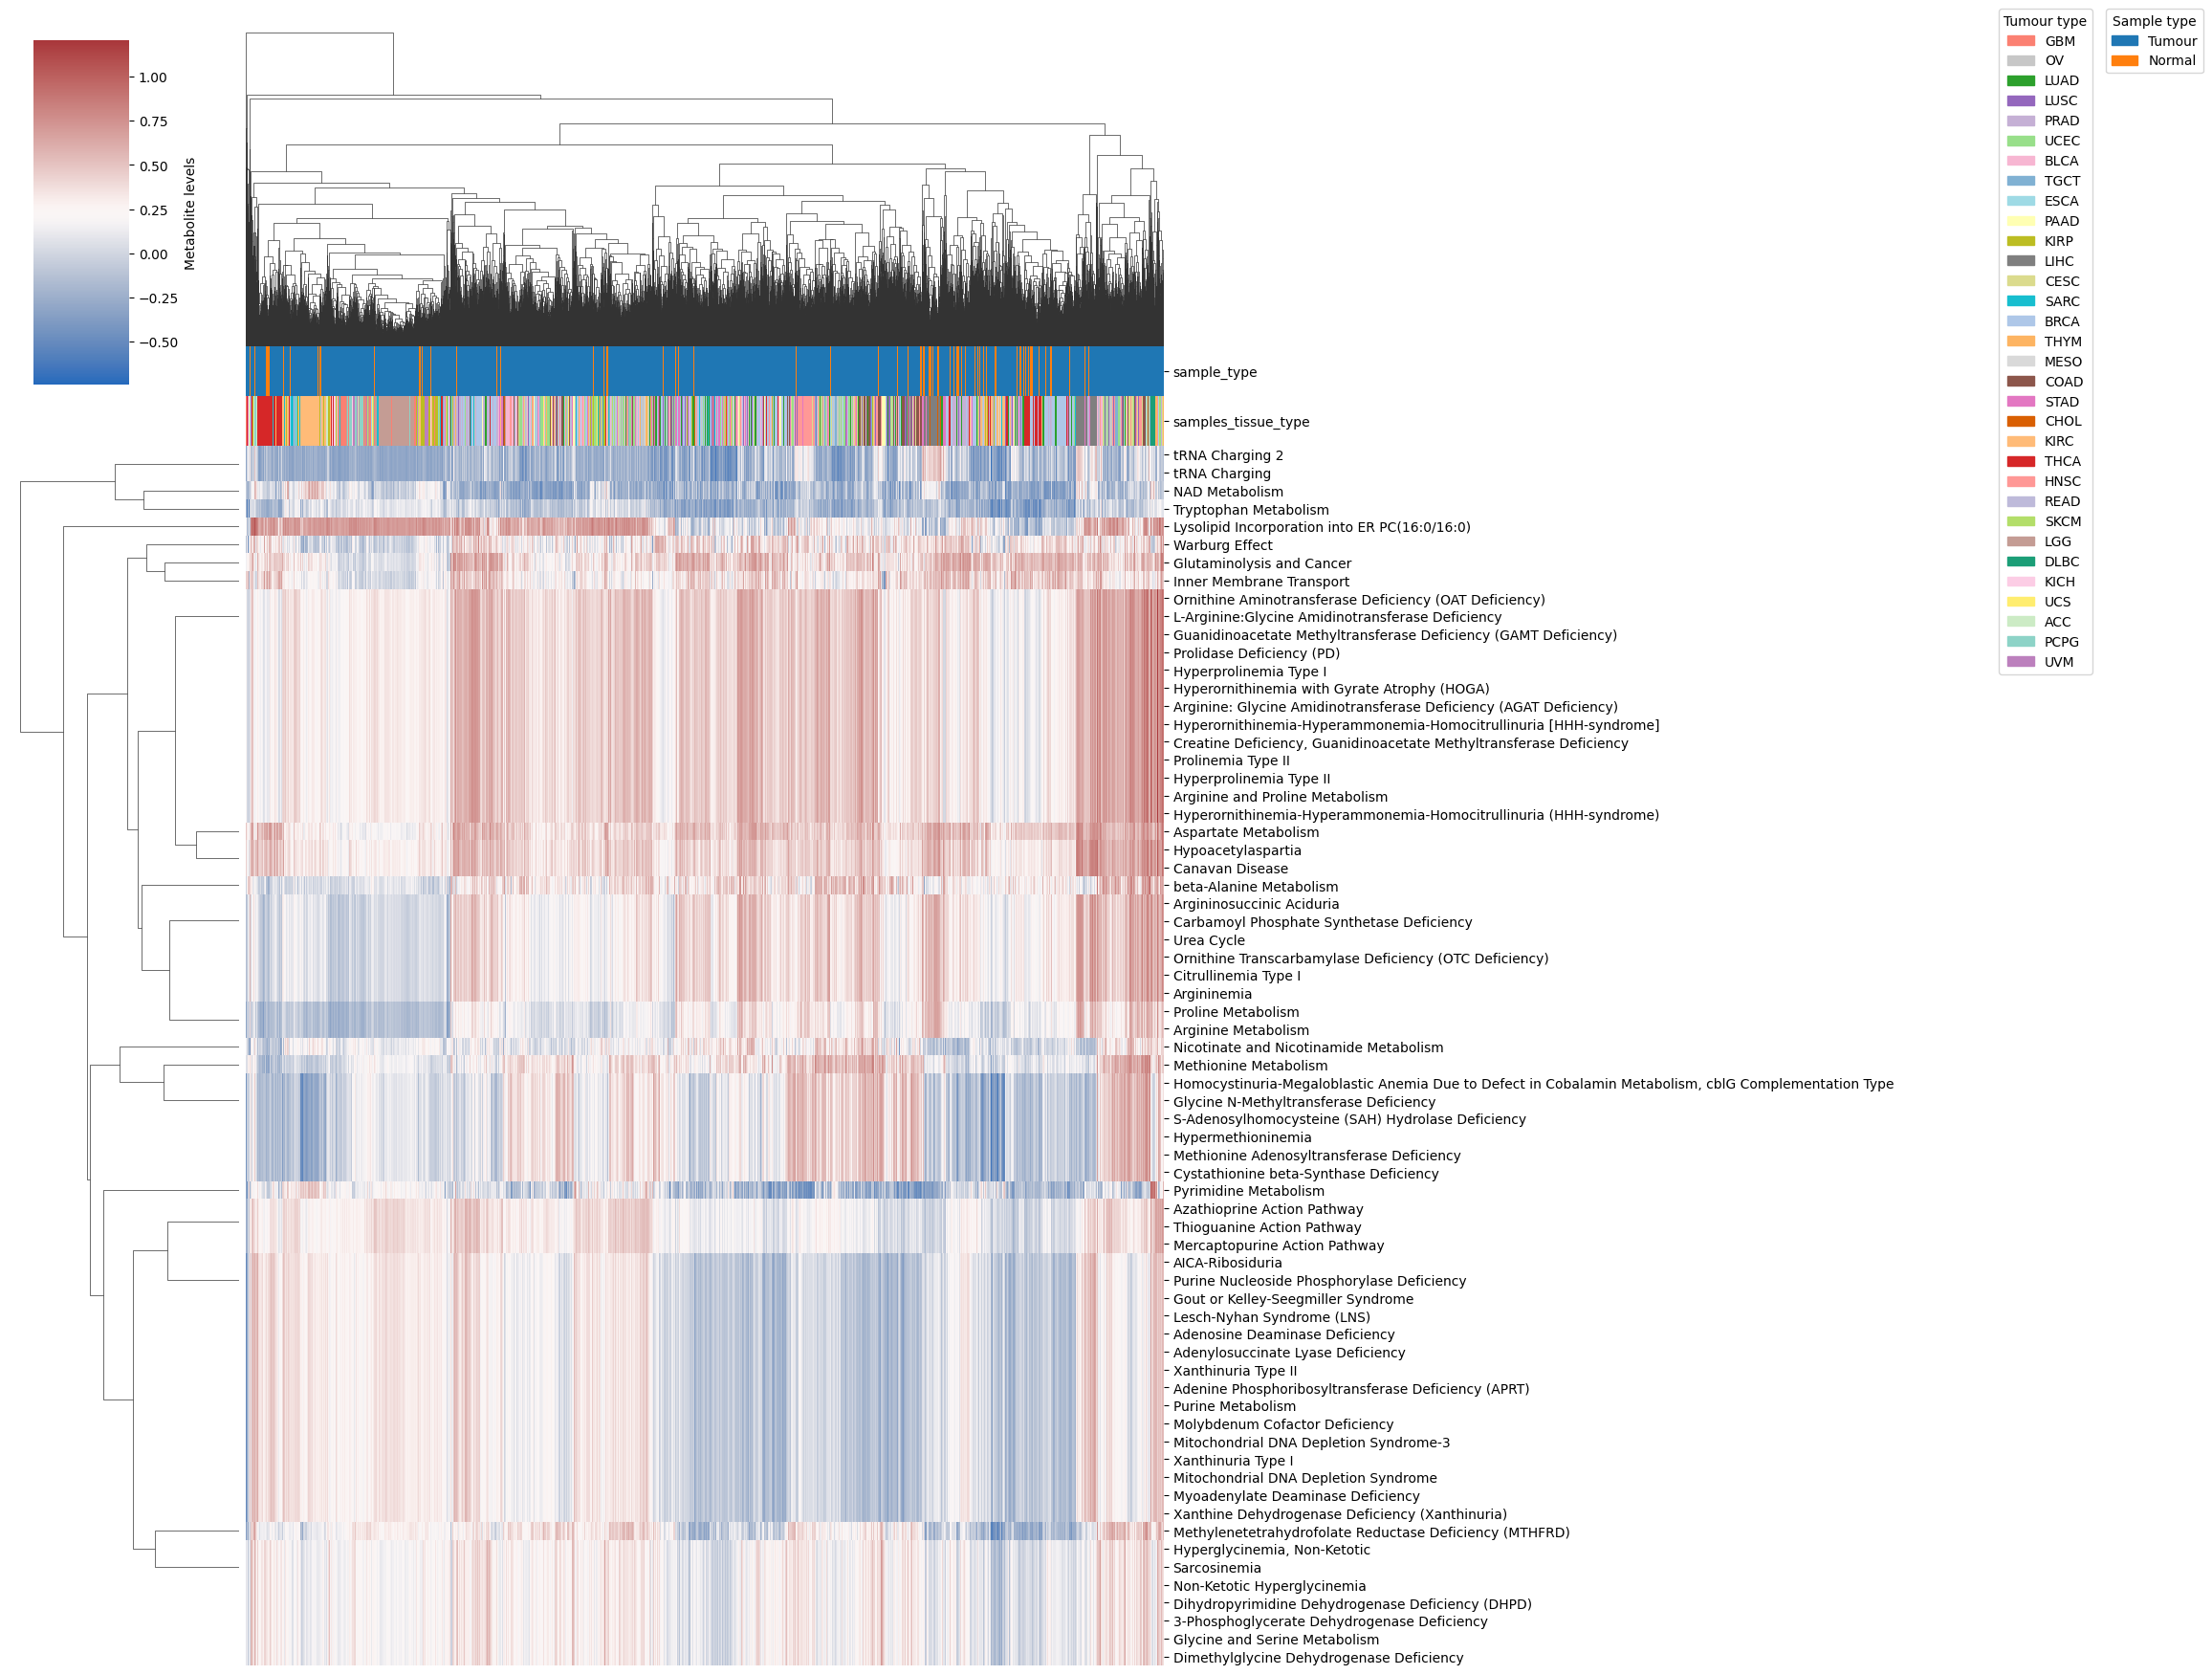

In [33]:
g = sns.clustermap(sspa_res,
                   cmap = cmap,
                   col_colors = col_colors,
                   figsize=(20,20)
                   )

plt.ylabel('Metabolite levels')
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

sample_type_patches = [mpatches.Patch(color=lut[label], label=label) for label in map_metadata['sample_type'].unique()]
samples_tissue_type_patches = [mpatches.Patch(color=lut[label], label=label) for label in map_metadata['samples_tissue_type'].unique()]

g.fig.legend(handles=sample_type_patches, title="Sample type", loc="upper left", bbox_to_anchor=(1.1, 1), ncol=1)
g.fig.legend(handles=samples_tissue_type_patches, title="Tumour type", loc="upper right", bbox_to_anchor=(1.1, 1), ncol=1)
g.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_metabolites_ensemble_nn_clustermap_sspa.svg', format = 'svg')

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


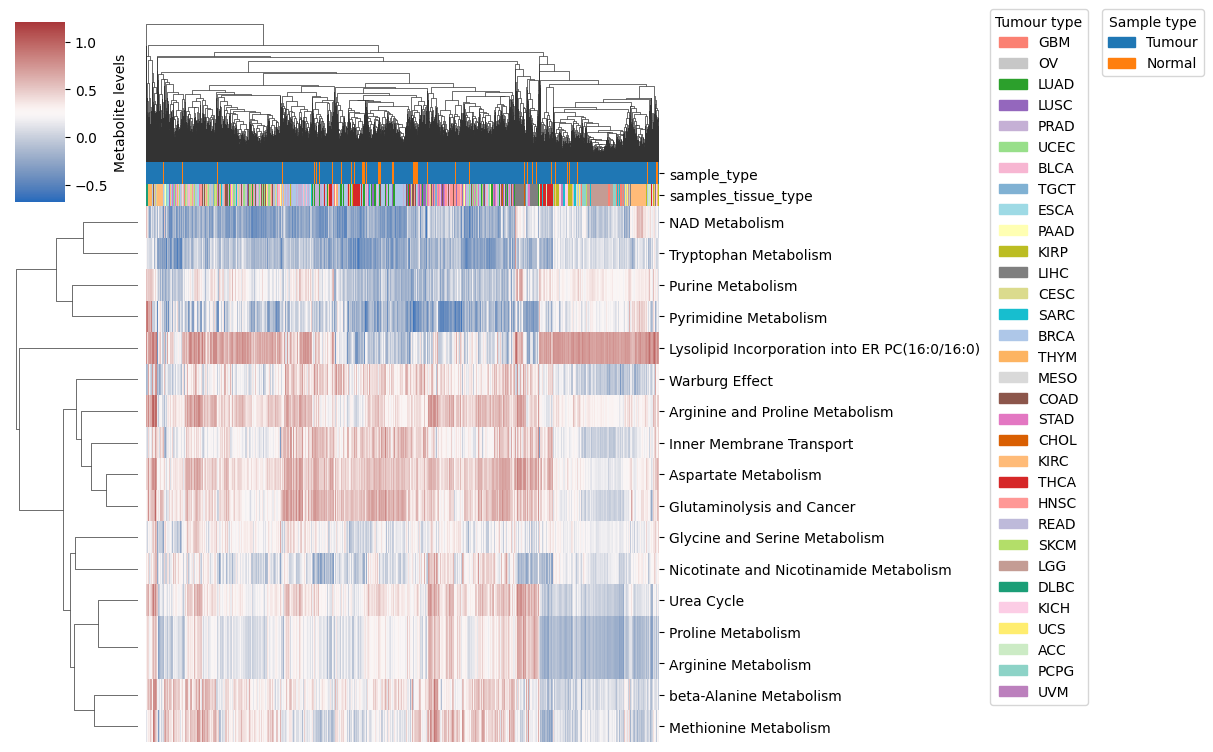

In [34]:
g = sns.clustermap(sspa_res_keep_cols,
                   cmap = cmap,
                   col_colors = col_colors,
                   figsize=(10,10)
                   )

plt.ylabel('Metabolite levels')
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

sample_type_patches = [mpatches.Patch(color=lut[label], label=label) for label in map_metadata['sample_type'].unique()]
samples_tissue_type_patches = [mpatches.Patch(color=lut[label], label=label) for label in map_metadata['samples_tissue_type'].unique()]

g.fig.legend(handles=sample_type_patches, title="Sample type", loc="upper left", bbox_to_anchor=(1.1, 1), ncol=1)
g.fig.legend(handles=samples_tissue_type_patches, title="Tumour type", loc="upper right", bbox_to_anchor=(1.1, 1), ncol=1)
g.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_metabolites_ensemble_nn_clustermap_sspa_selected.svg', format = 'svg')

plt.show()

In [35]:
pca1 = PCA(n_components=2)
pca1_result = pca1.fit_transform(sspa_res_keep_cols.T)
pca1_df = pd.DataFrame(pca1_result, columns = ['PC1', 'PC2'], index = sspa_res_keep_cols.columns)
pca1_df

,PC1,PC2
TCGA-D8-A146-01A-31R-A115-07,-0.572585,-0.407539
TCGA-AQ-A0Y5-01A-11R-A14M-07,0.199369,0.090936
TCGA-C8-A274-01A-11R-A16F-07,-0.193310,0.456865
TCGA-BH-A0BD-01A-11R-A034-07,-0.178737,-0.371722
TCGA-B6-A1KC-01B-11R-A157-07,0.380946,0.275640
...,...,...
TCGA-CV-7432-01A-11R-2132-07,0.032860,0.192626
TCGA-IQ-7630-01A-11R-2081-07,-0.267838,0.399858
TCGA-H7-A6C4-11A-21R-A466-07,0.159910,-0.320707
TCGA-H7-8501-01A-11R-2403-07,-0.600014,0.376890


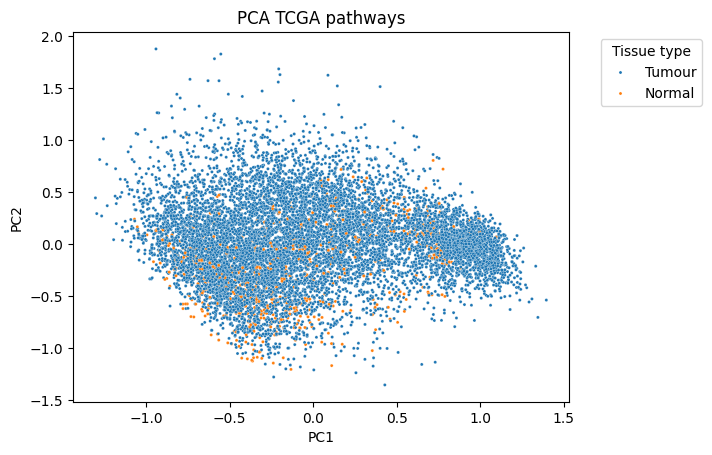

In [36]:
sns.scatterplot(data = pca1_df, x = 'PC1', y = 'PC2', hue = map_metadata['sample_type'], s = 5)
plt.title('PCA TCGA pathways')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title = 'Tissue type')
plt.show()

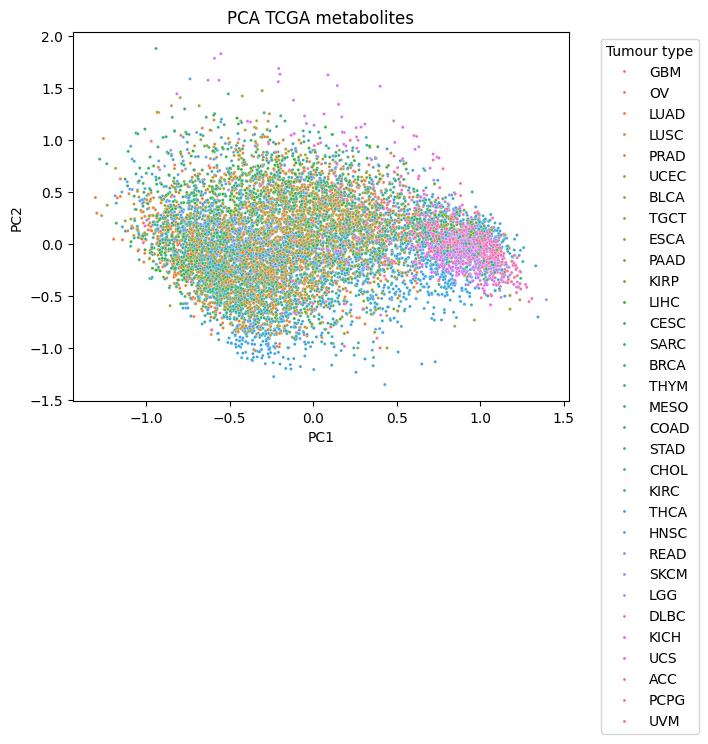

In [37]:
sns.scatterplot(data = pca1_df, x = 'PC1', y = 'PC2', hue = map_metadata['samples_tissue_type'], s = 5)
plt.title('PCA TCGA metabolites')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title = 'Tumour type')
plt.show()

In [38]:
!pip install umap-learn --quiet
import umap

In [39]:
reducer1 = umap.UMAP(n_components=2, n_neighbors = 5)
umap1_result = reducer1.fit_transform(sspa_res_keep_cols.T)
umap1_df = pd.DataFrame(umap1_result, columns = ['UMAP1', 'UMAP2'], index = sspa_res_keep_cols.columns)
umap1_df

,UMAP1,UMAP2
TCGA-D8-A146-01A-31R-A115-07,14.535868,-1.103071
TCGA-AQ-A0Y5-01A-11R-A14M-07,6.969657,2.136259
TCGA-C8-A274-01A-11R-A16F-07,6.187430,2.437166
TCGA-BH-A0BD-01A-11R-A034-07,12.436273,-3.739872
TCGA-B6-A1KC-01B-11R-A157-07,3.592539,-0.111722
...,...,...
TCGA-CV-7432-01A-11R-2132-07,6.134437,-2.292103
TCGA-IQ-7630-01A-11R-2081-07,6.588052,-0.056628
TCGA-H7-A6C4-11A-21R-A466-07,5.813898,-4.420020
TCGA-H7-8501-01A-11R-2403-07,10.523285,1.646014


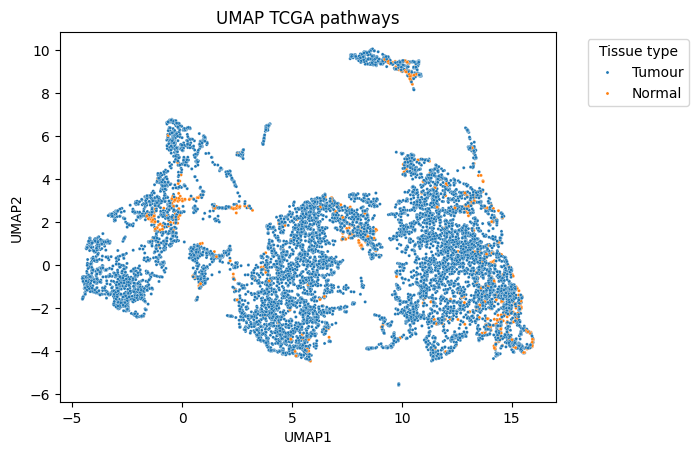

In [40]:
sns.scatterplot(data = umap1_df, x = 'UMAP1', y = 'UMAP2', hue = map_metadata['sample_type'], s = 5)
plt.title('UMAP TCGA pathways')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title = 'Tissue type')
plt.show()

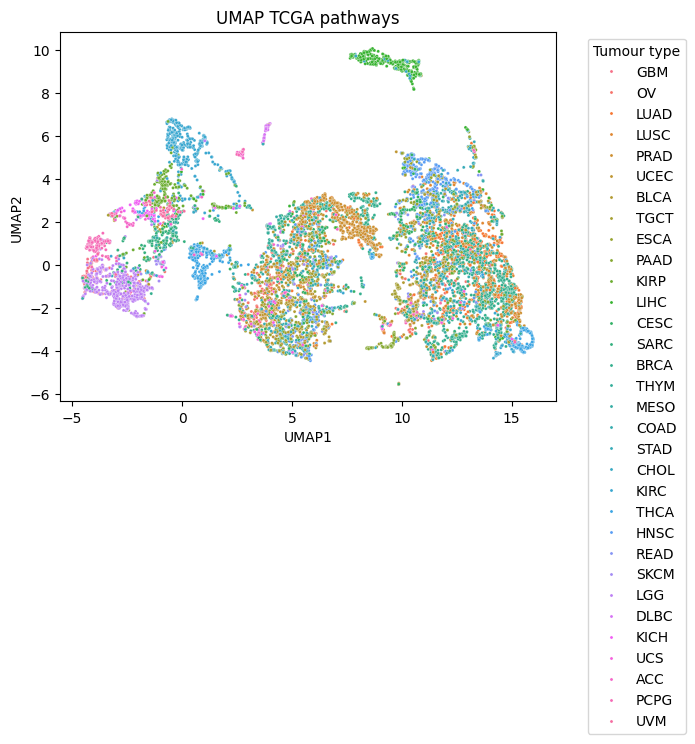

In [41]:
sns.scatterplot(data = umap1_df, x = 'UMAP1', y = 'UMAP2', hue = map_metadata['samples_tissue_type'], s = 5)
plt.title('UMAP TCGA pathways')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, title = 'Tumour type')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_pathways_ensemble_nn_umap.svg')
plt.show()

In [42]:
sspa_annot = pd.concat([annot[['sample_type', 'samples_tissue_type']], sspa_res_keep_cols.T], axis = 'columns')
sspa_annot['samples_tissue_type'] = sspa_annot['samples_tissue_type'].apply(lambda x: x.split('-')[1])
sspa_annot.head(3)

,sample_type,samples_tissue_type,Aspartate Metabolism,Glutaminolysis and Cancer,Inner Membrane Transport,NAD Metabolism,beta-Alanine Metabolism,Urea Cycle,Warburg Effect,Arginine and Proline Metabolism,Proline Metabolism,Arginine Metabolism,Glycine and Serine Metabolism,Purine Metabolism,Methionine Metabolism,Tryptophan Metabolism,Pyrimidine Metabolism,Lysolipid Incorporation into ER PC(16:0/16:0),Nicotinate and Nicotinamide Metabolism
TCGA-02-0047-01A-01R-1849-01,Tumour,GBM,0.121983,0.000355,-0.014675,0.105273,0.047135,-0.004689,-0.100055,0.295518,-0.155073,-0.155073,0.157774,0.325072,0.126843,0.146865,0.214416,0.709821,0.207898
TCGA-02-0055-01A-01R-1849-01,Tumour,GBM,0.210630,0.164618,0.252405,-0.018305,0.055131,0.083990,0.234002,0.390496,-0.075519,-0.075519,0.218887,0.261698,0.094194,0.190954,0.149212,0.703500,0.154445
TCGA-02-2483-01A-01R-1849-01,Tumour,GBM,0.206972,0.129413,0.044265,0.021207,0.122319,0.072455,0.148206,0.334204,-0.078433,-0.078433,0.136093,0.397833,0.184972,0.077802,0.338818,0.664999,0.160363


In [43]:
#Summarize pathways per tumour
sspa_annot_tumour_type = sspa_annot[sspa_annot['sample_type'] == 'Tumour'].drop(labels = ['sample_type'], axis = 'columns').groupby(['samples_tissue_type']).median()
sspa_annot_tumour_type

,Aspartate Metabolism,Glutaminolysis and Cancer,Inner Membrane Transport,NAD Metabolism,beta-Alanine Metabolism,Urea Cycle,Warburg Effect,Arginine and Proline Metabolism,Proline Metabolism,Arginine Metabolism,Glycine and Serine Metabolism,Purine Metabolism,Methionine Metabolism,Tryptophan Metabolism,Pyrimidine Metabolism,Lysolipid Incorporation into ER PC(16:0/16:0),Nicotinate and Nicotinamide Metabolism
samples_tissue_type,,,,,,,,,,,,,,,,,
ACC,0.329181,0.258175,0.139555,0.167186,0.167418,0.198558,0.244363,0.194103,0.052754,0.052754,0.266220,0.412725,0.075667,-0.120858,0.106742,0.801023,0.047461
BLCA,0.492765,0.419912,0.294634,-0.182749,0.344559,0.364437,0.299438,0.521119,0.245487,0.245487,0.257399,0.173664,0.313831,-0.134804,-0.122646,0.652934,0.160441
BRCA,0.493245,0.549030,0.440512,-0.339937,0.359783,0.351303,0.429090,0.420057,0.214419,0.214419,0.224605,-0.022083,0.171196,-0.182234,-0.042121,0.128780,0.145342
CESC,0.529558,0.430000,0.303859,-0.138060,0.550795,0.441855,0.275728,0.590570,0.319420,0.319420,0.266991,0.095648,0.516660,-0.113358,-0.054807,0.552746,0.350866
CHOL,0.484615,0.394261,0.328726,0.077913,0.260886,0.164196,0.094361,0.396356,-0.030668,-0.030668,0.307534,0.207468,0.238166,0.116683,0.111003,0.708119,0.107553
COAD,0.472658,0.379380,0.324155,-0.226031,0.390649,0.328888,0.275433,0.437298,0.208998,0.208998,0.300824,-0.019619,0.513268,-0.115478,-0.164610,0.483901,0.204360
DLBC,0.584063,0.473360,0.140401,0.415266,0.502637,0.628256,-0.038453,0.740200,0.467608,0.467608,0.152878,0.518196,0.325622,0.126494,0.902746,0.718615,0.368021
ESCA,0.412771,0.313192,0.257431,-0.190061,0.372576,0.331708,0.251083,0.422004,0.180880,0.180880,0.239346,0.110995,0.520881,-0.104228,-0.181183,0.508401,0.147754
GBM,0.158389,0.007536,0.037657,0.004513,0.047042,-0.050426,-0.098026,0.252642,-0.202752,-0.202752,0.157397,0.268760,0.083094,0.087908,0.209021,0.693206,0.102731


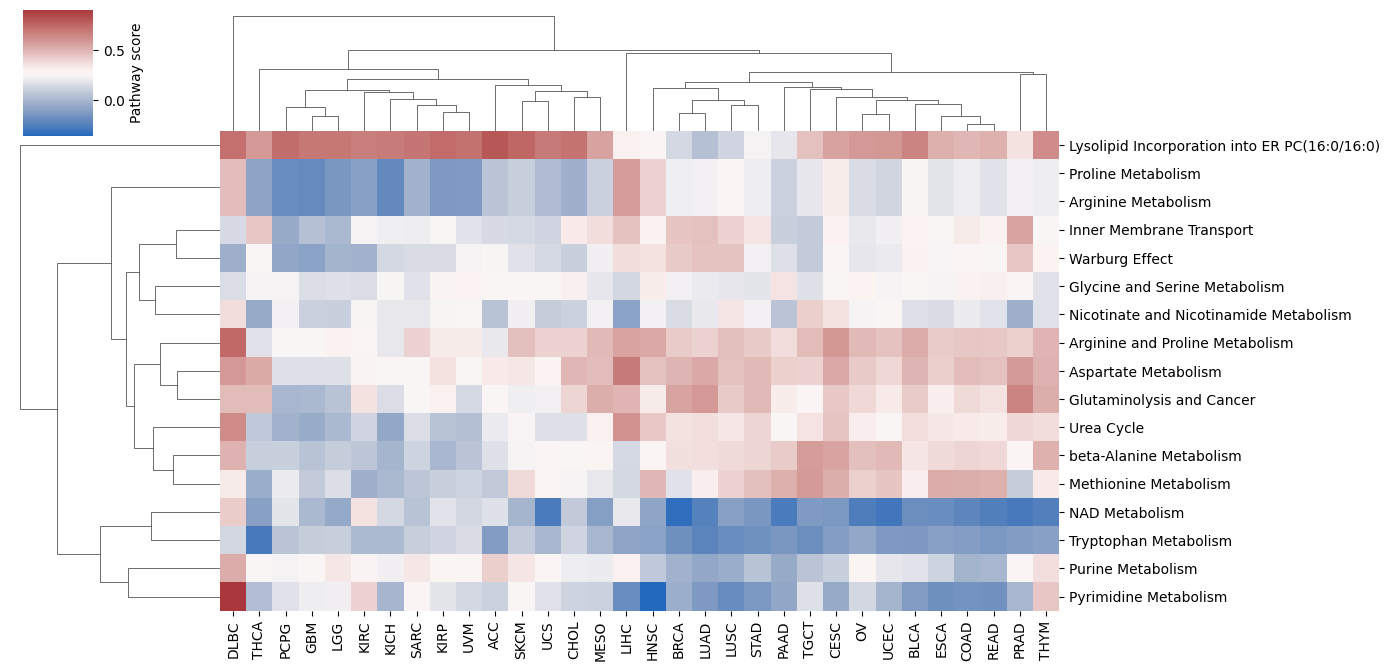

In [44]:
g = sns.clustermap(sspa_annot_tumour_type.T,
                   cmap = cmap,
                   figsize = (14,7))
g.ax_heatmap.set_xlabel('')
plt.ylabel('Pathway score')
g.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_pathways_per_tumour_clustermap.svg', format = 'svg')

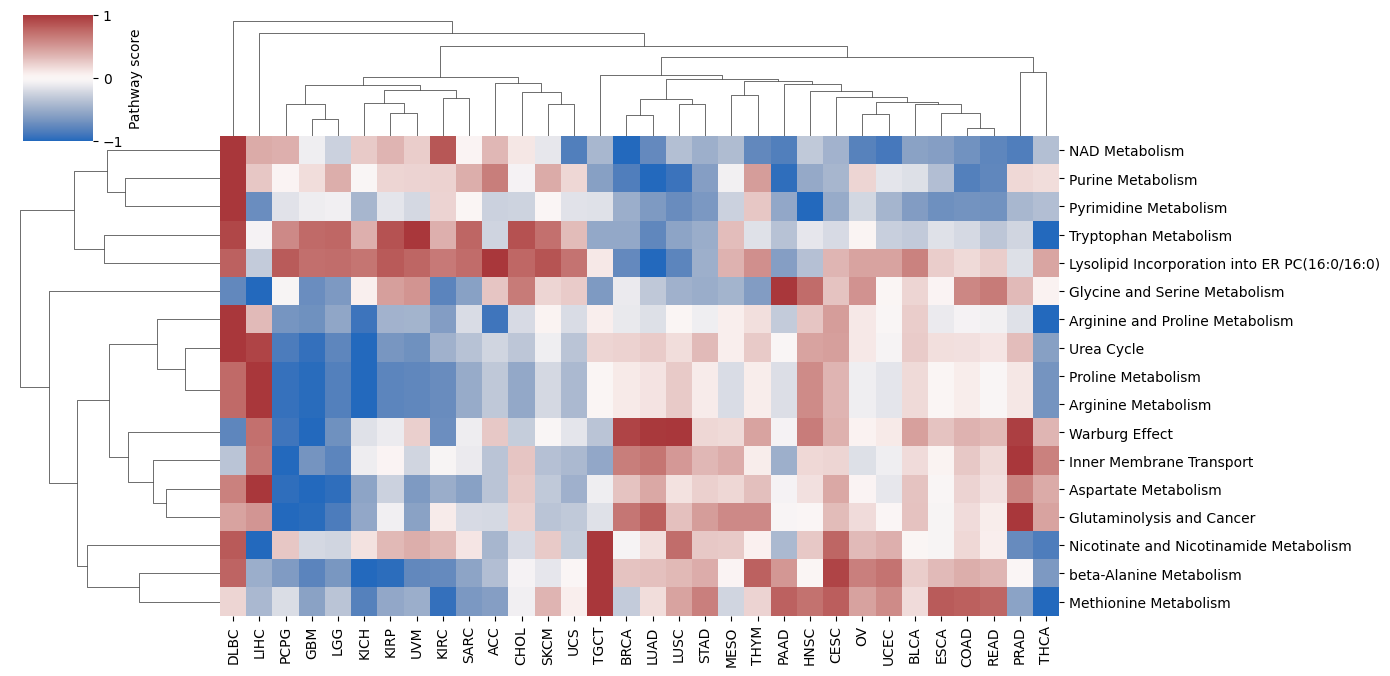

In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (-1, 1))
sspa_annot_tumour_type_normalized = pd.DataFrame(scaler.fit_transform(sspa_annot_tumour_type), index = sspa_annot_tumour_type.index, columns = sspa_annot_tumour_type.columns)
g = sns.clustermap(sspa_annot_tumour_type_normalized.T,
                   cmap = cmap,
                   figsize = (14,7))
g.ax_heatmap.set_xlabel('')
plt.ylabel('Pathway score')
g.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_pathways_per_tumour_clustermap_scaled.svg', format = 'svg')

#Data analysis and visualisation [Tumour vs Normal]

In [46]:
def get_log2FC(df, tumour_type):
  data = df.copy()
  data = data[data['samples_tissue_type'] == tumour_type]
  data_numeric = data.drop(columns=['samples_tissue_type'])
  res = pd.DataFrame(data_numeric.groupby(['sample_type']).median())
  res = res.T
  if 'Normal'in res.columns:
    res['log2FC'] = np.log2(res['Tumour'] / res['Normal'])
    res = res.drop(columns = {'Normal', 'Tumour'})
    res = res.rename(columns = {'log2FC' : tumour_type})
    res.index.name = None
    res.columns.name = None
    return res
  else:
    pass


In [47]:
tumour_types = metabolites.samples_tissue_type.value_counts().index.to_list()

df_plot = pd.DataFrame()

for i in tumour_types:
  df_plot = pd.concat([df_plot, get_log2FC(metabolites, i)], axis = 'columns')

df_plot

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = geta

,TCGA-BRCA,TCGA-KIRC,TCGA-LUAD,TCGA-UCEC,TCGA-THCA,TCGA-HNSC,TCGA-LUSC,TCGA-PRAD,TCGA-COAD,TCGA-STAD,...,TCGA-SARC,TCGA-ESCA,TCGA-PCPG,TCGA-PAAD,TCGA-READ,TCGA-GBM,TCGA-THYM,TCGA-SKCM,TCGA-KICH,TCGA-CHOL
histamine,-0.079960,0.084599,0.491813,0.504570,0.239522,0.502489,0.177383,-0.078273,0.485931,0.334861,...,0.043258,-0.322976,NaN,0.634680,0.858875,-0.551156,-0.055403,0.155180,0.262840,1.087062
stearoylcarnitine,NaN,2.499282,1.779376,NaN,0.404079,0.047319,2.720995,-0.601133,-0.404772,-1.361594,...,1.218910,-0.891786,-3.826432,NaN,0.752191,-1.775257,0.178460,NaN,-5.233916,-3.866335
hippurate,0.195306,0.980241,0.181992,-0.179833,0.390861,0.192325,0.203885,0.366901,0.723868,0.781457,...,0.435535,0.785782,NaN,-0.186340,0.864121,0.265876,-0.176727,-0.142674,0.748476,NaN
aspartate,-0.627444,-0.397487,-0.338368,-0.425626,0.307490,0.794501,-0.745499,0.081543,-0.611140,-0.352796,...,-0.571346,-0.517247,-0.342443,0.051400,-0.630426,-1.421002,-0.045924,0.107799,-1.005524,-1.511715
taurine,0.331122,NaN,0.549045,0.933307,-0.393999,0.216672,0.706909,0.030853,0.194012,-0.270618,...,0.046541,-0.692864,NaN,NaN,0.895017,-0.778387,0.656840,-0.732399,0.213797,-0.528726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
glycine,-1.641139,-0.372518,NaN,-0.901436,0.167379,-0.550353,5.399252,-0.085843,NaN,NaN,...,-0.217562,-0.052205,0.036241,-0.537569,NaN,-0.015129,NaN,NaN,-0.062632,0.130328
5-oxoproline,-0.578432,-0.912315,1.849871,-1.293527,0.495960,-0.812052,0.952064,0.258332,NaN,-2.736774,...,-0.254427,-0.262162,0.042017,-0.055884,NaN,0.020318,NaN,NaN,0.026138,0.675372
xanthosine,-0.173628,-0.683579,2.204016,-2.011672,0.334013,-0.440021,1.122633,NaN,NaN,-5.156919,...,-0.309372,-0.458901,0.070269,NaN,NaN,0.005350,-3.063437,NaN,-0.038431,0.410128
hypoxanthine,-0.680557,-0.986439,1.688598,-1.231832,0.532049,-0.722543,0.812844,0.014108,NaN,-2.899518,...,-0.262290,-0.266503,0.015992,-0.182289,NaN,-0.022017,NaN,NaN,0.010945,0.774149


In [48]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (-1, 1))
df_plot = pd.DataFrame(scaler.fit_transform(df_plot), columns = df_plot.columns, index = df_plot.index)
df_plot

,TCGA-BRCA,TCGA-KIRC,TCGA-LUAD,TCGA-UCEC,TCGA-THCA,TCGA-HNSC,TCGA-LUSC,TCGA-PRAD,TCGA-COAD,TCGA-STAD,...,TCGA-SARC,TCGA-ESCA,TCGA-PCPG,TCGA-PAAD,TCGA-READ,TCGA-GBM,TCGA-THYM,TCGA-SKCM,TCGA-KICH,TCGA-CHOL
histamine,0.216266,-0.560583,-0.277803,0.290953,0.089382,0.129025,0.273835,-0.255907,0.160731,0.148590,...,0.122953,0.112902,NaN,0.146124,0.241017,-0.488129,0.341398,0.558999,0.306812,0.780096
stearoylcarnitine,NaN,0.022707,0.121030,NaN,0.115980,-0.032505,0.627556,-0.369401,0.034063,-0.165109,...,0.330234,-0.110025,-0.871806,NaN,0.218030,-0.803037,0.422544,NaN,-1.000000,-0.013545
hippurate,0.300986,-0.344232,-0.373773,0.119297,0.113843,0.018954,0.277521,-0.159275,0.194568,0.231172,...,0.192116,0.547445,NaN,-0.164179,0.242147,-0.277942,0.299300,0.445850,0.422269,NaN
aspartate,0.047764,-0.677035,-0.534958,0.057650,0.100368,0.232653,0.145498,-0.221216,0.004715,0.021432,...,0.014592,0.036763,0.558300,-0.074326,-0.079875,-0.711903,0.344687,0.541000,0.005268,0.363716
taurine,0.342787,NaN,-0.260075,0.398484,-0.013014,0.027595,0.347472,-0.232219,0.119217,0.036628,...,0.123532,-0.032064,NaN,NaN,0.248804,-0.546585,0.588534,0.221824,0.295153,0.521212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
glycine,-0.264227,-0.671004,NaN,-0.061688,0.077722,-0.244606,1.000000,-0.257550,NaN,NaN,...,0.076968,0.219022,0.713742,-0.296925,NaN,-0.350232,NaN,NaN,0.229434,0.626806
5-oxoproline,0.062848,-0.801397,0.142867,-0.160028,0.130830,-0.337477,0.381564,-0.182841,NaN,-0.419400,...,0.070468,0.136736,0.716113,-0.114873,NaN,-0.341113,NaN,NaN,0.250538,0.714134
xanthosine,0.187437,-0.746144,0.252566,-0.340147,0.104655,-0.205451,0.405284,NaN,NaN,-0.866921,...,0.060781,0.059630,0.727710,NaN,NaN,-0.344964,-0.702339,NaN,0.235187,0.671636
hypoxanthine,0.031417,-0.819302,0.092911,-0.144555,0.136663,-0.305712,0.362204,-0.235854,NaN,-0.449494,...,0.069082,0.135035,0.705430,-0.162648,NaN,-0.352004,NaN,NaN,0.246926,0.729960


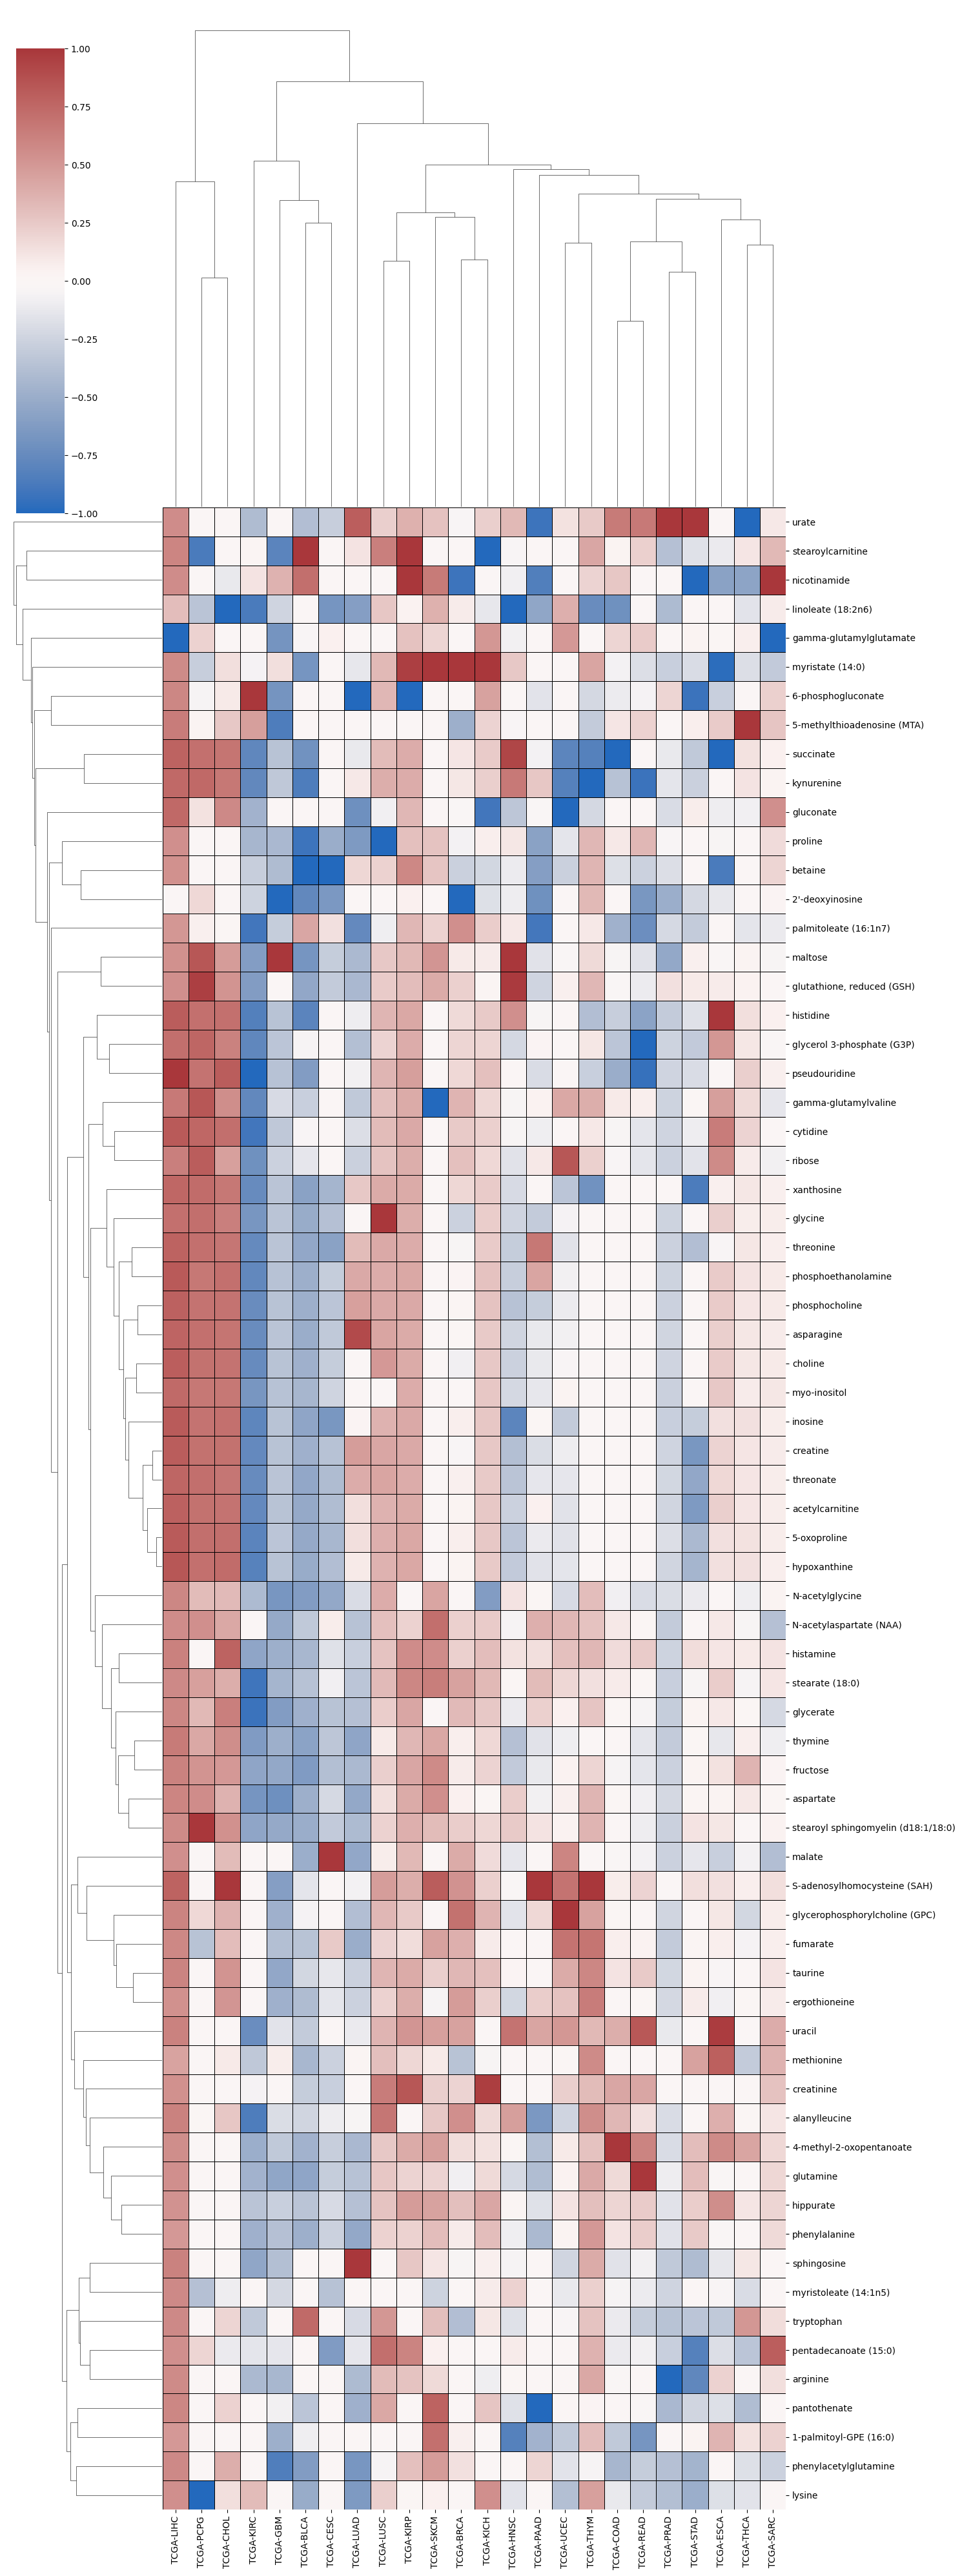

In [49]:
sns.clustermap(df_plot.fillna(0), figsize=(15,40), cmap = cmap, linewidths = 0.5, linecolor = 'black')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_metabolite_ensemble_nn_clustermap.svg')
plt.show()

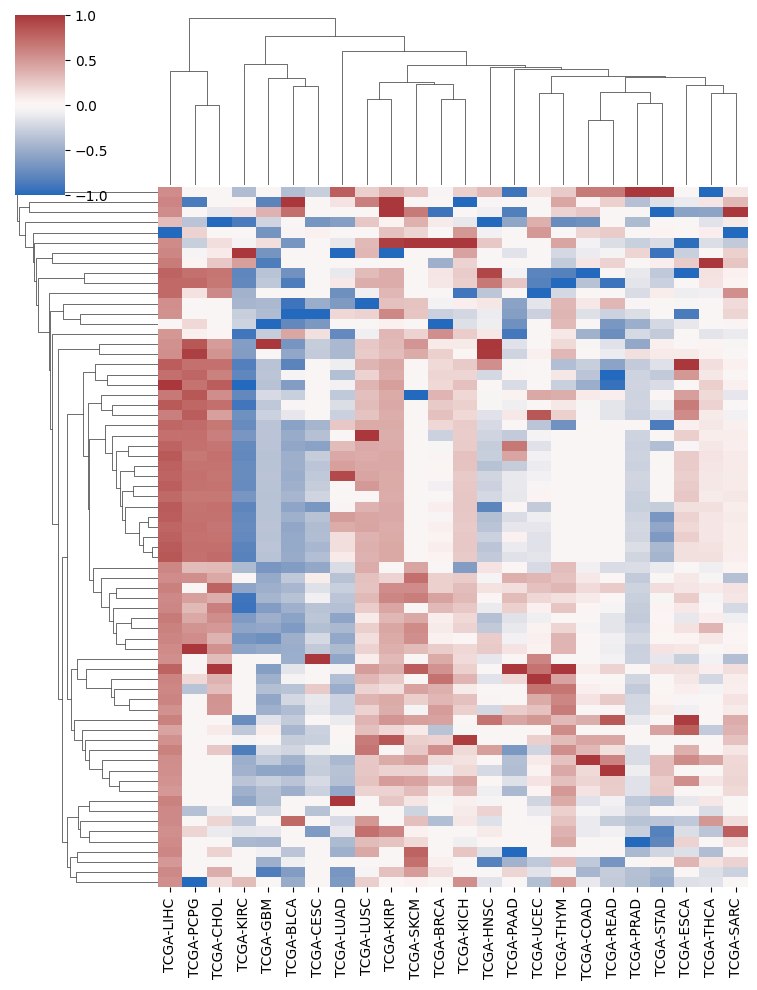

In [50]:
g = sns.clustermap(df_plot.fillna(0), cmap = cmap)
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_ylabel('')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_metabolite_ensemble_nn_clustermap_wo_metabolite_names.svg')
plt.show()

#BRCA analysis PI3K mutation [Metabolites]

In [51]:
brca_annotations = pd.read_csv('drive/My Drive/Colab Notebooks/GP_lab_data/BRCA1_project/TCGA/TCGA_DESeq2/TCGA_BRCA_annotation_withCNV.txt', sep = '\t')
brca_annotations

,Transcriptomic_Sample,Tumour,HR_status,HER2_status,TNBC_status,PI3K_mutation_status,PTEN_status,PI3K_activity_status,MYC_status,Disease_Stage,PAM50_Classification
0,TCGA-3C-AAAU-01A-11R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_Deletion,PI3K_PTEN_mut,MYC_WT,NaN,LumA
1,TCGA-3C-AALI-01A-11R-A41B-07,Tumour,HR+,HER2+,TNBC-,PI3K_WT,PTEN_Deletion,PI3K_PTEN_mut,MYC_Gain,Stage_II,Her2
2,TCGA-3C-AALJ-01A-31R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_WT,PI3K_PTEN_WT,MYC_Amplification,Stage_II,LumB
3,TCGA-3C-AALK-01A-11R-A41B-07,Tumour,HR+,HER2+,TNBC-,PI3K_mut,PTEN_WT,PI3K_PTEN_mut,MYC_WT,Stage_I,LumA
4,TCGA-4H-AAAK-01A-12R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_WT,PI3K_PTEN_WT,MYC_Gain,Stage_III,LumA
...,...,...,...,...,...,...,...,...,...,...,...
1219,TCGA-WT-AB44-01A-11R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_mut,PTEN_WT,PI3K_PTEN_mut,MYC_WT,Stage_I,LumA
1220,TCGA-XX-A899-01A-11R-A36F-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_WT,PI3K_PTEN_WT,MYC_WT,Stage_III,LumA
1221,TCGA-XX-A89A-01A-11R-A36F-07,Tumour,HR+,HER2-,TNBC-,PI3K_mut,PTEN_WT,PI3K_PTEN_mut,MYC_WT,Stage_II,LumA
1222,TCGA-Z7-A8R5-01A-42R-A41B-07,Tumour,HR+,HER2-,TNBC-,PI3K_WT,PTEN_WT,PI3K_PTEN_WT,MYC_WT,Stage_III,LumA


In [52]:
tumour_samples = brca_annotations[(brca_annotations['Tumour'] != 'Normal')]['Transcriptomic_Sample']
tumour_samples = list(tumour_samples)
len(tumour_samples)

1111

In [53]:
pi3k_status = brca_annotations[brca_annotations['Transcriptomic_Sample'].isin(tumour_samples)][['Transcriptomic_Sample', 'PI3K_activity_status']]
pi3k_status = pi3k_status.replace('PI3K_PTEN_mut', 'PI3K_PTEN_MUT')
pi3k_status = pi3k_status.set_index('Transcriptomic_Sample')
pi3k_status.index.name = None
pi3k_status

,PI3K_activity_status
TCGA-3C-AAAU-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-3C-AALI-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-3C-AALJ-01A-31R-A41B-07,PI3K_PTEN_WT
TCGA-3C-AALK-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-4H-AAAK-01A-12R-A41B-07,PI3K_PTEN_WT
...,...
TCGA-WT-AB44-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-XX-A899-01A-11R-A36F-07,PI3K_PTEN_WT
TCGA-XX-A89A-01A-11R-A36F-07,PI3K_PTEN_MUT
TCGA-Z7-A8R5-01A-42R-A41B-07,PI3K_PTEN_WT


In [54]:
metabolites.head(3)

,sample_type,samples_tissue_type,histamine,stearoylcarnitine,hippurate,aspartate,taurine,palmitoleate (16:1n7),creatinine,sphingosine,...,ribose,myo-inositol,phosphocholine,threonate,"glutathione, reduced (GSH)",glycine,5-oxoproline,xanthosine,hypoxanthine,asparagine
TCGA-02-0047-01A-01R-1849-01,Tumour,TCGA-GBM,0.438751,0.174190,-0.194369,0.251118,0.404562,0.060826,-0.028997,0.024204,...,0.545640,0.891619,0.857276,0.815357,-0.431716,0.774531,0.829175,0.783448,0.811115,0.839788
TCGA-02-0055-01A-01R-1849-01,Tumour,TCGA-GBM,0.388314,0.214898,-0.339983,0.208430,0.615005,0.126682,-0.149219,-0.015704,...,0.261733,0.772575,0.611412,0.568787,-0.433918,0.631726,0.541211,0.522824,0.521643,0.618691
TCGA-02-2483-01A-01R-1849-01,Tumour,TCGA-GBM,0.428232,0.029381,-0.307771,0.180158,0.269336,-0.017946,-0.050872,-0.060907,...,0.404210,0.879451,0.800819,0.743920,-0.295814,0.723579,0.737094,0.693916,0.727737,0.773105


In [55]:
metabolites_brca = metabolites[metabolites.index.isin(tumour_samples)]
metabolites_brca.head(2)

,sample_type,samples_tissue_type,histamine,stearoylcarnitine,hippurate,aspartate,taurine,palmitoleate (16:1n7),creatinine,sphingosine,...,ribose,myo-inositol,phosphocholine,threonate,"glutathione, reduced (GSH)",glycine,5-oxoproline,xanthosine,hypoxanthine,asparagine
TCGA-3C-AAAU-01A-11R-A41B-07,Tumour,TCGA-BRCA,0.508080,-0.023945,-0.207889,-0.008805,0.235700,0.156908,-0.024884,-0.087827,...,-0.432765,-0.092850,-0.245292,-0.261331,-0.228539,-0.160501,-0.293253,-0.295142,-0.309147,-0.255814
TCGA-3C-AALI-01A-11R-A41B-07,Tumour,TCGA-BRCA,0.245059,0.189061,-0.233457,0.247091,0.412093,0.013318,-0.086161,0.020048,...,-0.387237,-0.240031,-0.399323,-0.408868,-0.237682,-0.364049,-0.443820,-0.410769,-0.447888,-0.379453


In [56]:
metabolites_brca = pd.concat([pi3k_status, metabolites_brca], axis = 'columns')
metabolites_brca = metabolites_brca.drop(columns = ['sample_type', 'samples_tissue_type'])
metabolites_brca.head(2)

,PI3K_activity_status,histamine,stearoylcarnitine,hippurate,aspartate,taurine,palmitoleate (16:1n7),creatinine,sphingosine,methionine,...,ribose,myo-inositol,phosphocholine,threonate,"glutathione, reduced (GSH)",glycine,5-oxoproline,xanthosine,hypoxanthine,asparagine
TCGA-3C-AAAU-01A-11R-A41B-07,PI3K_PTEN_MUT,0.508080,-0.023945,-0.207889,-0.008805,0.235700,0.156908,-0.024884,-0.087827,-0.131886,...,-0.432765,-0.092850,-0.245292,-0.261331,-0.228539,-0.160501,-0.293253,-0.295142,-0.309147,-0.255814
TCGA-3C-AALI-01A-11R-A41B-07,PI3K_PTEN_MUT,0.245059,0.189061,-0.233457,0.247091,0.412093,0.013318,-0.086161,0.020048,0.007876,...,-0.387237,-0.240031,-0.399323,-0.408868,-0.237682,-0.364049,-0.443820,-0.410769,-0.447888,-0.379453


In [57]:
metabolites_brca.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/tcga_metabolites_pi3k.csv', index = True)

In [58]:
metabolites_brca_grouped = metabolites_brca.groupby(['PI3K_activity_status']).median()
metabolites_brca_grouped = metabolites_brca_grouped.T
metabolites_brca_grouped['log2FC'] = np.log2(metabolites_brca_grouped['PI3K_PTEN_MUT'] / metabolites_brca_grouped['PI3K_PTEN_WT'])
metabolites_brca_grouped = metabolites_brca_grouped.drop(columns = ['PI3K_PTEN_WT', 'PI3K_PTEN_MUT'])
metabolites_brca_grouped.index.name = None
metabolites_brca_grouped = metabolites_brca_grouped.sort_values(by = 'log2FC', ascending = False)
metabolites_brca_grouped

PI3K_activity_status,log2FC
2'-deoxyinosine,1.353015
arginine,0.946148
myo-inositol,0.915630
stearoylcarnitine,0.323659
tryptophan,0.290592
...,...
palmitoleate (16:1n7),-0.160863
gluconate,-0.203010
lysine,-0.225576
N-acetylglycine,-0.349350


In [59]:
names_hmdb_dict

{'1-palmitoyl-GPE (16:0)': 'HMDB0011503',
 "2'-deoxyinosine": 'HMDB0000071',
 '4-methyl-2-oxopentanoate': 'HMDB0000695',
 '5-methylthioadenosine (MTA)': 'HMDB0001173',
 '5-oxoproline': 'HMDB0000267',
 '6-phosphogluconate': 'HMDB0001316',
 'acetylcarnitine': 'HMDB0000201',
 'alanylleucine': 'HMDB0028691',
 'arginine': 'HMDB0000517',
 'asparagine': 'HMDB0000168',
 'aspartate': 'HMDB0000191',
 'betaine': 'HMDB0000043',
 'choline': 'HMDB0000097',
 'phosphocholine': 'HMDB0001565',
 'creatine': 'HMDB0000064',
 'creatinine': 'HMDB0000562',
 'cytidine': 'HMDB0000089',
 'ergothioneine': 'HMDB0003045',
 'fructose': 'HMDB0000660',
 'fumarate': 'HMDB0000134',
 'gamma-glutamylglutamate': 'HMDB0011737',
 'gamma-glutamylvaline': 'HMDB0011172',
 'gluconate': 'HMDB0000625',
 'glutamine': 'HMDB0000641',
 'glutathione, reduced (GSH)': 'HMDB0000125',
 'glycerate': 'HMDB0000139',
 'glycerol 3-phosphate (G3P)': 'HMDB0000126',
 'glycerophosphorylcholine (GPC)': 'HMDB0000086',
 'glycine': 'HMDB0000123',
 'hip

In [60]:
metabolites_brca_grouped_renamed = metabolites_brca_grouped.rename(index = names_hmdb_dict)
metabolites_brca_grouped_renamed

PI3K_activity_status,log2FC
HMDB0000071,1.353015
HMDB0000517,0.946148
HMDB0000211,0.915630
HMDB0000848,0.323659
HMDB0000929,0.290592
...,...
HMDB0003229,-0.160863
HMDB0000625,-0.203010
HMDB0000182,-0.225576
HMDB0000532,-0.349350


In [61]:
metabolites_brca_grouped_renamed.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/log2FC_tcga.csv', index = True)

In [62]:
import pickle
met_up_down = {}
met_up_down['up'] = metabolites_brca_grouped_renamed[metabolites_brca_grouped_renamed['log2FC'] > 0].index.to_list()
met_up_down['down'] = metabolites_brca_grouped_renamed[metabolites_brca_grouped_renamed['log2FC'] < 0].index.to_list()

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/tcga_mets_up_down.pkl', 'wb') as f:
    pickle.dump(met_up_down, f)

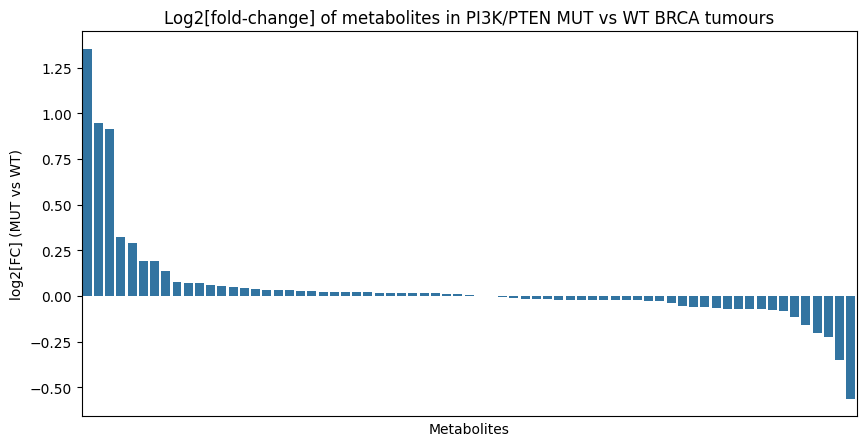

In [63]:
plt.figure(figsize = (10, 5))
sns.barplot(data = metabolites_brca_grouped, x = metabolites_brca_grouped.index, y = 'log2FC')
plt.xticks([])
plt.xlabel('Metabolites')
plt.ylabel('log2[FC] (MUT vs WT)')
plt.title('Log2[fold-change] of metabolites in PI3K/PTEN MUT vs WT BRCA tumours')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BRCA_metabolites_ensemble_nn_log2FC.svg')
plt.show()

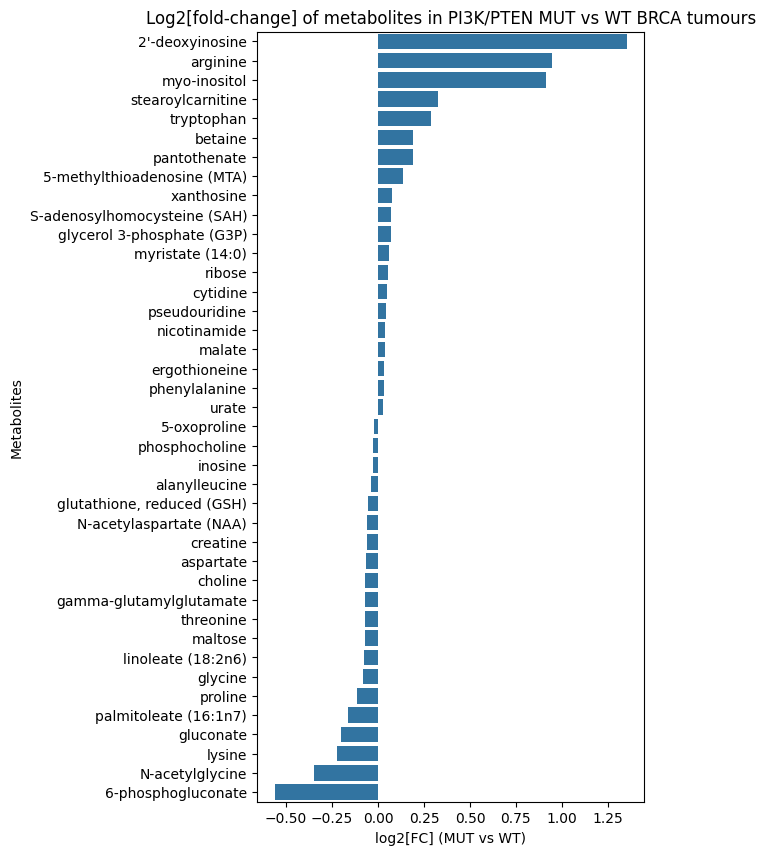

In [64]:
metabolites_brca_grouped_top = pd.concat([metabolites_brca_grouped.head(20), metabolites_brca_grouped.tail(20)], axis = 'index')
plt.figure(figsize = (5, 10))
sns.barplot(data = metabolites_brca_grouped_top, x ='log2FC', y =  metabolites_brca_grouped_top.index)
plt.ylabel('Metabolites')
plt.xlabel('log2[FC] (MUT vs WT)')
plt.title('Log2[fold-change] of metabolites in PI3K/PTEN MUT vs WT BRCA tumours')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BRCA_top_metabolites_ensemble_nn_log2FC.svg')
plt.show()

#BRCA analysis PI3K mutation [Metabolic pathways]

In [65]:
sspa_annot.head(3)

,sample_type,samples_tissue_type,Aspartate Metabolism,Glutaminolysis and Cancer,Inner Membrane Transport,NAD Metabolism,beta-Alanine Metabolism,Urea Cycle,Warburg Effect,Arginine and Proline Metabolism,Proline Metabolism,Arginine Metabolism,Glycine and Serine Metabolism,Purine Metabolism,Methionine Metabolism,Tryptophan Metabolism,Pyrimidine Metabolism,Lysolipid Incorporation into ER PC(16:0/16:0),Nicotinate and Nicotinamide Metabolism
TCGA-02-0047-01A-01R-1849-01,Tumour,GBM,0.121983,0.000355,-0.014675,0.105273,0.047135,-0.004689,-0.100055,0.295518,-0.155073,-0.155073,0.157774,0.325072,0.126843,0.146865,0.214416,0.709821,0.207898
TCGA-02-0055-01A-01R-1849-01,Tumour,GBM,0.210630,0.164618,0.252405,-0.018305,0.055131,0.083990,0.234002,0.390496,-0.075519,-0.075519,0.218887,0.261698,0.094194,0.190954,0.149212,0.703500,0.154445
TCGA-02-2483-01A-01R-1849-01,Tumour,GBM,0.206972,0.129413,0.044265,0.021207,0.122319,0.072455,0.148206,0.334204,-0.078433,-0.078433,0.136093,0.397833,0.184972,0.077802,0.338818,0.664999,0.160363


In [66]:
pi3k_status

,PI3K_activity_status
TCGA-3C-AAAU-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-3C-AALI-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-3C-AALJ-01A-31R-A41B-07,PI3K_PTEN_WT
TCGA-3C-AALK-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-4H-AAAK-01A-12R-A41B-07,PI3K_PTEN_WT
...,...
TCGA-WT-AB44-01A-11R-A41B-07,PI3K_PTEN_MUT
TCGA-XX-A899-01A-11R-A36F-07,PI3K_PTEN_WT
TCGA-XX-A89A-01A-11R-A36F-07,PI3K_PTEN_MUT
TCGA-Z7-A8R5-01A-42R-A41B-07,PI3K_PTEN_WT


In [67]:
sspa_annot_brca = sspa_annot.reindex(pi3k_status.index, axis = 'index')
sspa_annot_brca = pd.concat([pi3k_status, sspa_annot_brca], axis = 'columns')
sspa_annot_brca = sspa_annot_brca.drop(columns = ['sample_type', 'samples_tissue_type'])
sspa_annot_brca.head(3)

,PI3K_activity_status,Aspartate Metabolism,Glutaminolysis and Cancer,Inner Membrane Transport,NAD Metabolism,beta-Alanine Metabolism,Urea Cycle,Warburg Effect,Arginine and Proline Metabolism,Proline Metabolism,Arginine Metabolism,Glycine and Serine Metabolism,Purine Metabolism,Methionine Metabolism,Tryptophan Metabolism,Pyrimidine Metabolism,Lysolipid Incorporation into ER PC(16:0/16:0),Nicotinate and Nicotinamide Metabolism
TCGA-3C-AAAU-01A-11R-A41B-07,PI3K_PTEN_MUT,0.317092,0.362418,0.180178,-0.480967,0.410106,0.179284,0.519033,0.166532,0.039329,0.039329,0.262609,0.029742,0.406127,-0.258942,0.185370,0.182800,0.088352
TCGA-3C-AALI-01A-11R-A41B-07,PI3K_PTEN_MUT,0.610904,0.593290,0.324275,-0.331645,0.668355,0.565285,0.347489,0.606799,0.462565,0.462565,0.285960,-0.163323,0.436926,-0.269411,-0.108933,0.068396,0.250475
TCGA-3C-AALJ-01A-31R-A41B-07,PI3K_PTEN_WT,0.480003,0.451095,0.204090,-0.457635,0.466022,0.425069,0.180889,0.542365,0.272097,0.272097,0.013902,-0.076318,0.400275,-0.372923,-0.096270,0.025903,0.175842


In [68]:
sspa_annot_brca_grouped = sspa_annot_brca.groupby(['PI3K_activity_status']).median()
sspa_annot_brca_grouped = sspa_annot_brca_grouped.T
sspa_annot_brca_grouped['log2FC'] = np.log2(sspa_annot_brca_grouped['PI3K_PTEN_MUT'] / sspa_annot_brca_grouped['PI3K_PTEN_WT'])
sspa_annot_brca_grouped = sspa_annot_brca_grouped.drop(columns = ['PI3K_PTEN_WT', 'PI3K_PTEN_MUT'])
sspa_annot_brca_grouped.index.name = None
sspa_annot_brca_grouped = sspa_annot_brca_grouped.sort_values(by = 'log2FC', ascending = False)
sspa_annot_brca_grouped

PI3K_activity_status,log2FC
Lysolipid Incorporation into ER PC(16:0/16:0),0.279633
beta-Alanine Metabolism,0.119524
Inner Membrane Transport,0.091993
Arginine and Proline Metabolism,0.089051
Nicotinate and Nicotinamide Metabolism,0.069966
Proline Metabolism,0.040313
Arginine Metabolism,0.040313
Glutaminolysis and Cancer,0.038011
Aspartate Metabolism,0.036511
Urea Cycle,0.032968


In [69]:
sspa_annot_brca_grouped.to_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/results/log2fc_ssPA_tcga.csv', index = True)

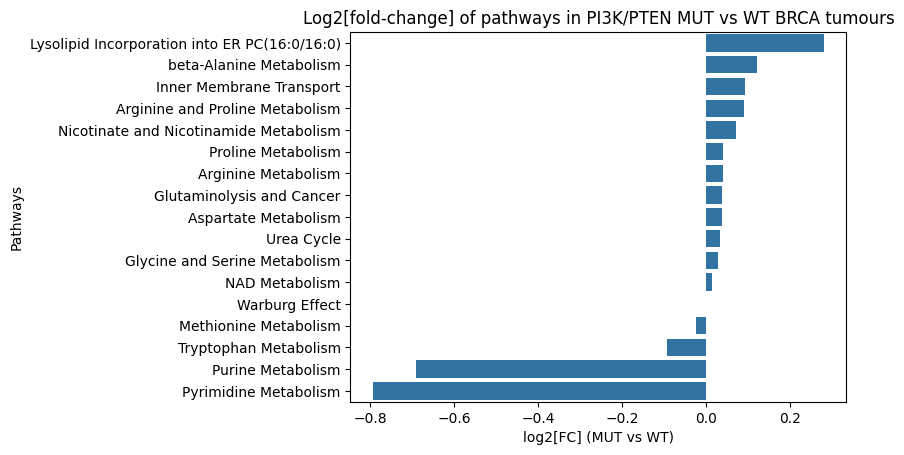

In [70]:
sns.barplot(data = sspa_annot_brca_grouped, x ='log2FC', y =  sspa_annot_brca_grouped.index)
plt.ylabel('Pathways')
plt.xlabel('log2[FC] (MUT vs WT)')
plt.title('Log2[fold-change] of pathways in PI3K/PTEN MUT vs WT BRCA tumours')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BRCA_pathways_ensemble_nn_log2FC.svg')
plt.show()

In [71]:
sspa_annot_brca_grouped_rank = sspa_annot_brca_grouped
sspa_annot_brca_grouped_rank['abs(log2FC)'] = np.abs(sspa_annot_brca_grouped_rank['log2FC'])
sspa_annot_brca_grouped_rank = sspa_annot_brca_grouped_rank.sort_values(by = 'abs(log2FC)', ascending = False)
sspa_annot_brca_grouped_rank['rank'] = [16-i+1 for i in range(0, sspa_annot_brca_grouped_rank.shape[0])]
sspa_annot_brca_grouped_rank

PI3K_activity_status,log2FC,abs(log2FC),rank
Pyrimidine Metabolism,-0.794063,0.794063,17
Purine Metabolism,-0.692451,0.692451,16
Lysolipid Incorporation into ER PC(16:0/16:0),0.279633,0.279633,15
beta-Alanine Metabolism,0.119524,0.119524,14
Tryptophan Metabolism,-0.094851,0.094851,13
Inner Membrane Transport,0.091993,0.091993,12
Arginine and Proline Metabolism,0.089051,0.089051,11
Nicotinate and Nicotinamide Metabolism,0.069966,0.069966,10
Proline Metabolism,0.040313,0.040313,9
Arginine Metabolism,0.040313,0.040313,8


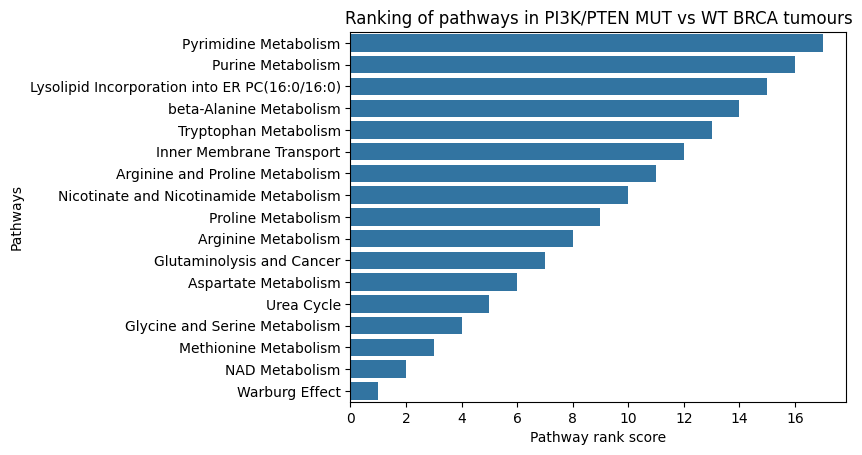

In [72]:
sns.barplot(data = sspa_annot_brca_grouped_rank, x ='rank', y =  sspa_annot_brca_grouped_rank.index)
plt.ylabel('Pathways')
plt.xlabel('Pathway rank score')
plt.title('Ranking of pathways in PI3K/PTEN MUT vs WT BRCA tumours')
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/BRCA_pathways_ensemble_nn_ranking.svg', bbox_inches = 'tight')
plt.show()

#Oncogenic pathways analysis

In [73]:
barcodes = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan/TCGA_Samples_Tissue_Type.csv')
barcodes

,sample_barcode,patient_barcorde,sample_type,samples_tissue_type
0,TCGA-02-0047-01A-01R-1849-01,TCGA-02-0047,Tumour,TCGA-GBM
1,TCGA-02-0055-01A-01R-1849-01,TCGA-02-0055,Tumour,TCGA-GBM
2,TCGA-02-2483-01A-01R-1849-01,TCGA-02-2483,Tumour,TCGA-GBM
3,TCGA-02-2485-01A-01R-1849-01,TCGA-02-2485,Tumour,TCGA-GBM
4,TCGA-02-2486-01A-01R-1849-01,TCGA-02-2486,Tumour,TCGA-GBM
...,...,...,...,...
10663,TCGA-ZS-A9CG-01A-11R-A37K-07,TCGA-ZS-A9CG,Tumour,TCGA-LIHC
10664,TCGA-ZT-A8OM-01A-11R-A42S-07,TCGA-ZT-A8OM,Tumour,TCGA-THYM
10665,TCGA-ZU-A8S4-01A-11R-A41I-07,TCGA-ZU-A8S4,Tumour,TCGA-CHOL
10666,TCGA-ZU-A8S4-11A-11R-A41I-07,TCGA-ZU-A8S4,Normal,TCGA-CHOL


In [74]:
barcodes_dict = dict(zip(barcodes['patient_barcorde'], barcodes['sample_barcode']))
barcodes_dict

{'TCGA-02-0047': 'TCGA-02-0047-01A-01R-1849-01',
 'TCGA-02-0055': 'TCGA-02-0055-01A-01R-1849-01',
 'TCGA-02-2483': 'TCGA-02-2483-01A-01R-1849-01',
 'TCGA-02-2485': 'TCGA-02-2485-01A-01R-1849-01',
 'TCGA-02-2486': 'TCGA-02-2486-01A-01R-1849-01',
 'TCGA-04-1331': 'TCGA-04-1331-01A-01R-1569-13',
 'TCGA-04-1332': 'TCGA-04-1332-01A-01R-1564-13',
 'TCGA-04-1337': 'TCGA-04-1337-01A-01R-1564-13',
 'TCGA-04-1338': 'TCGA-04-1338-01A-01R-1564-13',
 'TCGA-04-1341': 'TCGA-04-1341-01A-01R-1564-13',
 'TCGA-04-1343': 'TCGA-04-1343-01A-01R-1564-13',
 'TCGA-04-1347': 'TCGA-04-1347-01A-01R-1564-13',
 'TCGA-04-1348': 'TCGA-04-1348-01A-01R-1565-13',
 'TCGA-04-1350': 'TCGA-04-1350-01A-01R-1565-13',
 'TCGA-04-1356': 'TCGA-04-1356-01A-01R-1569-13',
 'TCGA-04-1357': 'TCGA-04-1357-01A-01R-1565-13',
 'TCGA-04-1361': 'TCGA-04-1361-01A-01R-1565-13',
 'TCGA-04-1362': 'TCGA-04-1362-01A-01R-1565-13',
 'TCGA-04-1364': 'TCGA-04-1364-01A-01R-1565-13',
 'TCGA-04-1365': 'TCGA-04-1365-01A-01R-1565-13',
 'TCGA-04-1514': 'TC

In [75]:
oncogenic = pd.read_excel('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/mmc4.xlsx', sheet_name=2, index_col = 0)
oncogenic.index.name = None
oncogenic.index = oncogenic.index.map(lambda x: x.replace('-01', ''))
oncogenic = oncogenic.fillna(0)
oncogenic = oncogenic.astype('int64')
oncogenic

,Cell Cycle,HIPPO,MYC,NOTCH,NRF2,PI3K,RTK RAS,TP53,TGF-Beta,WNT
TCGA-OR-A5J1,1,0,0,0,0,1,1,1,0,0
TCGA-OR-A5J2,0,0,0,1,0,0,1,1,0,0
TCGA-OR-A5J3,0,0,0,0,0,0,0,0,0,0
TCGA-OR-A5J5,0,0,0,0,0,1,0,1,0,0
TCGA-OR-A5J6,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
TCGA-YZ-A980,0,1,0,0,0,0,0,0,0,0
TCGA-YZ-A982,0,0,0,0,0,0,0,0,0,0
TCGA-YZ-A983,0,0,0,0,0,0,0,0,0,0
TCGA-YZ-A984,0,0,0,0,0,0,0,0,0,0


In [76]:
oncogenic = oncogenic.rename(index = barcodes_dict)
oncogenic

,Cell Cycle,HIPPO,MYC,NOTCH,NRF2,PI3K,RTK RAS,TP53,TGF-Beta,WNT
TCGA-OR-A5J1-01A-11R-A29S-07,1,0,0,0,0,1,1,1,0,0
TCGA-OR-A5J2-01A-11R-A29S-07,0,0,0,1,0,0,1,1,0,0
TCGA-OR-A5J3-01A-11R-A29S-07,0,0,0,0,0,0,0,0,0,0
TCGA-OR-A5J5-01A-11R-A29S-07,0,0,0,0,0,1,0,1,0,0
TCGA-OR-A5J6-01A-31R-A29S-07,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
TCGA-YZ-A980-01A-11R-A405-07,0,1,0,0,0,0,0,0,0,0
TCGA-YZ-A982-01A-11R-A405-07,0,0,0,0,0,0,0,0,0,0
TCGA-YZ-A983-01A-11R-A405-07,0,0,0,0,0,0,0,0,0,0
TCGA-YZ-A984-01A-11R-A405-07,0,0,0,0,0,0,0,0,0,0


In [77]:
sspa_annot.head(3)

,sample_type,samples_tissue_type,Aspartate Metabolism,Glutaminolysis and Cancer,Inner Membrane Transport,NAD Metabolism,beta-Alanine Metabolism,Urea Cycle,Warburg Effect,Arginine and Proline Metabolism,Proline Metabolism,Arginine Metabolism,Glycine and Serine Metabolism,Purine Metabolism,Methionine Metabolism,Tryptophan Metabolism,Pyrimidine Metabolism,Lysolipid Incorporation into ER PC(16:0/16:0),Nicotinate and Nicotinamide Metabolism
TCGA-02-0047-01A-01R-1849-01,Tumour,GBM,0.121983,0.000355,-0.014675,0.105273,0.047135,-0.004689,-0.100055,0.295518,-0.155073,-0.155073,0.157774,0.325072,0.126843,0.146865,0.214416,0.709821,0.207898
TCGA-02-0055-01A-01R-1849-01,Tumour,GBM,0.210630,0.164618,0.252405,-0.018305,0.055131,0.083990,0.234002,0.390496,-0.075519,-0.075519,0.218887,0.261698,0.094194,0.190954,0.149212,0.703500,0.154445
TCGA-02-2483-01A-01R-1849-01,Tumour,GBM,0.206972,0.129413,0.044265,0.021207,0.122319,0.072455,0.148206,0.334204,-0.078433,-0.078433,0.136093,0.397833,0.184972,0.077802,0.338818,0.664999,0.160363


In [78]:
metabolites.head(3)

,sample_type,samples_tissue_type,histamine,stearoylcarnitine,hippurate,aspartate,taurine,palmitoleate (16:1n7),creatinine,sphingosine,...,ribose,myo-inositol,phosphocholine,threonate,"glutathione, reduced (GSH)",glycine,5-oxoproline,xanthosine,hypoxanthine,asparagine
TCGA-02-0047-01A-01R-1849-01,Tumour,TCGA-GBM,0.438751,0.174190,-0.194369,0.251118,0.404562,0.060826,-0.028997,0.024204,...,0.545640,0.891619,0.857276,0.815357,-0.431716,0.774531,0.829175,0.783448,0.811115,0.839788
TCGA-02-0055-01A-01R-1849-01,Tumour,TCGA-GBM,0.388314,0.214898,-0.339983,0.208430,0.615005,0.126682,-0.149219,-0.015704,...,0.261733,0.772575,0.611412,0.568787,-0.433918,0.631726,0.541211,0.522824,0.521643,0.618691
TCGA-02-2483-01A-01R-1849-01,Tumour,TCGA-GBM,0.428232,0.029381,-0.307771,0.180158,0.269336,-0.017946,-0.050872,-0.060907,...,0.404210,0.879451,0.800819,0.743920,-0.295814,0.723579,0.737094,0.693916,0.727737,0.773105


In [79]:
def get_common_index(df1, df2):
  df1_index = df1.index.to_list()
  df2_index = df2.index.to_list()
  common_index = list(set(df1_index) & set(df2_index))
  return common_index

In [80]:
from sklearn.preprocessing import MinMaxScaler
def plot_oncogenic_metabolic_pathways(df, tumour):
  #Select tumour

  df_annot_tumour = df[df['samples_tissue_type'] == tumour]



  #2. Find common index
  c_index = get_common_index(oncogenic, df_annot_tumour)

  #3. Concat pathway s
  combo_df = pd.concat(
                       [oncogenic.loc[c_index],
                        df_annot_tumour.loc[c_index]],
                        axis = 'columns').drop(columns = ['sample_type', 'samples_tissue_type'])


  #4. Group per pathway
  def get_log2FC(df, pathway):
    df_res = df.groupby(pathway).median().T
    df_res.columns.name = None
    if df_res.shape[1] == 2:
      df_res = df_res.rename(columns = {1 : 'active', 0 : 'inactive'})
      df_res[pathway] = np.log2(df_res['active'] / df_res['inactive'])
      df_res = df_res.drop(columns = ['inactive', 'active'])
      return df_res
    else:
      pass


  res = pd.DataFrame()
  for i in oncogenic.columns:
    pathway_res = get_log2FC(combo_df, i)
    if pathway_res is not None:
      if res.empty:
        res = pathway_res
      else:
        res = pd.concat([res, pathway_res], axis = 'columns')

  res = res.loc[df_annot_tumour.drop(columns = ['sample_type', 'samples_tissue_type']).columns.to_list()]
  res = res.replace(np.nan, 0)
  res = res.replace(np.inf, 1)
  res = res.replace(-np.inf, -1)


  scaler = MinMaxScaler(feature_range = (-1, 1))
  res = pd.DataFrame(scaler.fit_transform(res.T).T, columns = res.columns, index = res.index)

  #Clustermap
  g = sns.clustermap(res, cmap = cmap)
  g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90)
  g.ax_heatmap.set_title(tumour, fontsize=16, fontweight='bold')
  plt.ylabel('Normalized score')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_pathways_{tumour}.svg', format = 'svg')
  plt.show()

for i in sspa_annot.samples_tissue_type.unique():
  plot_oncogenic_metabolic_pathways(df = sspa_annot, tumour = i)

Output hidden; open in https://colab.research.google.com to view.

In [81]:
metabolites.head(2)

,sample_type,samples_tissue_type,histamine,stearoylcarnitine,hippurate,aspartate,taurine,palmitoleate (16:1n7),creatinine,sphingosine,...,ribose,myo-inositol,phosphocholine,threonate,"glutathione, reduced (GSH)",glycine,5-oxoproline,xanthosine,hypoxanthine,asparagine
TCGA-02-0047-01A-01R-1849-01,Tumour,TCGA-GBM,0.438751,0.174190,-0.194369,0.251118,0.404562,0.060826,-0.028997,0.024204,...,0.545640,0.891619,0.857276,0.815357,-0.431716,0.774531,0.829175,0.783448,0.811115,0.839788
TCGA-02-0055-01A-01R-1849-01,Tumour,TCGA-GBM,0.388314,0.214898,-0.339983,0.208430,0.615005,0.126682,-0.149219,-0.015704,...,0.261733,0.772575,0.611412,0.568787,-0.433918,0.631726,0.541211,0.522824,0.521643,0.618691


In [82]:
def plot_oncogenic_metabolic_pathways(df, tumour):

  #Select tumour
  df_annot_tumour = df[df['samples_tissue_type'] == tumour]



  #2. Find common index
  c_index = get_common_index(oncogenic, df_annot_tumour)

  #3. Concat pathway s
  combo_df = pd.concat(
                       [oncogenic.loc[c_index],
                        df_annot_tumour.loc[c_index]],
                        axis = 'columns').drop(columns = ['sample_type', 'samples_tissue_type'])

  #4. Group per pathway
  def get_log2FC(df, pathway):
    df_res = df.groupby(pathway).median().T
    df_res.columns.name = None
    if df_res.shape[1] == 2:
      df_res = df_res.rename(columns = {1 : 'active', 0 : 'inactive'})
      df_res[pathway] = np.log2(df_res['active'] / df_res['inactive'])
      df_res = df_res.drop(columns = ['inactive', 'active'])
      return df_res
    else:
      pass


  res = pd.DataFrame()
  for i in oncogenic.columns:
    met_res = get_log2FC(combo_df, i)
    if met_res is not None:
      if res.empty:
        res = met_res
      else:
        res = pd.concat([res, met_res], axis = 'columns')

  res = res.loc[df_annot_tumour.drop(columns = ['sample_type', 'samples_tissue_type']).columns.to_list()]
  res = res.replace(np.nan, 0)
  res = res.replace(np.inf, 1)
  res = res.replace(-np.inf, -1)


  scaler = MinMaxScaler(feature_range = (-1, 1))
  res = pd.DataFrame(scaler.fit_transform(res.T).T, columns = res.columns, index = res.index)

  #Clustermap
  g = sns.clustermap(res, cmap = cmap, figsize = (10, 20))
  g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90)
  g.ax_heatmap.set_title(tumour, fontsize=16, fontweight='bold')
  plt.ylabel('Normalized score')
  plt.savefig(f'drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/TCGA_metabolites_{tumour}.svg', format = 'svg')
  plt.show()

for i in metabolites.samples_tissue_type.unique():
  plot_oncogenic_metabolic_pathways(df = metabolites, tumour = i)

Output hidden; open in https://colab.research.google.com to view.